# 1. Extract captive power plants

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Read spreadsheet (assumes Excel format)
df = pd.read_excel(r'./data/captive_power_plants/Merge/3.Results/captive_plants.xlsx')
df = df[df['em_fact'] != 0]
df = df[df['mw'] != 0]
df = df[~df['status_adj'].isin(['Cancelled', 'Retired', 'Shelved'])]

In [3]:
# First, filter fuel column
fuel_filter = df['fuel_class'].isin(['COAL', 'OIL', 'GAS'])

# Define values to match in bustype column
bustype_list = [
    'MFG: METALS & MINING',
    'MFG: CEMENT & BUILDING MA',
    'MFG: CHEMICALS & PETROCHE',
    'MFG: EQUIPMENT & MACHINER',
    'MFG: FOOD PRODUCTS',
    'MFG: PULP & PAPER & FORES',
    'MFG: SUGAR MILLS & FACTOR',
    'MFG: TEXTILES & CLOTHING',
    'MFG: OTHER & UNSPECIFIED',
    'FUELS: GAS',
    'FUELS: COAL',
    'FUELS: GAS & OIL',
    'FUELS: OIL & REFINERIES'
    
]

bustype_filter = df['bustype'].isin(bustype_list)

# Combine filter conditions
captive_plants = df[fuel_filter & bustype_filter].copy()

In [4]:
# Mapping dictionary: original bustype -> concise label
bustype_labels = {
    "MFG: CHEMICALS & PETROCHE": "Chemical",
    "MFG: METALS & MINING": "Metal & mining",
    "MFG: PULP & PAPER & FORES": "Papermaking",
    "MFG: EQUIPMENT & MACHINER": "Machinery",
    "MFG: FOOD PRODUCTS": "Agriculture",
    "MFG: CEMENT & BUILDING MA": "Cement",
    "MFG: TEXTILES & CLOTHING": "Textile",
    "MFG: SUGAR MILLS & FACTOR": "Sugar",
    "MFG: OTHER & UNSPECIFIED": "Others",
    'FUELS: GAS': "Fuel",
    'FUELS: COAL': "Fuel",
    'FUELS: GAS & OIL': "Fuel",
    'FUELS: OIL & REFINERIES': "Chemical"
}

# Apply mapping
captive_plants['bustype_short'] = captive_plants['bustype'].map(bustype_labels)

In [5]:
# --- Read files ---
cf_coal_df   = pd.read_excel(r'./data/capacity_factor/Capacity_factor.xlsx', sheet_name='Coal')[['ISO3', 'CF']]
cf_gas_df    = pd.read_excel(r'./data/capacity_factor/Capacity_factor.xlsx', sheet_name='Gas')[['ISO3', 'CF']]
cf_region_df = pd.read_excel(r'./data/capacity_factor/Capacity_factor.xlsx', sheet_name='Region')
country_list = pd.read_excel(r'./data/BasicData/GlobalCountryCode/CountryList.xlsx', sheet_name='Sheet2')[['Alpha-3 code', 'Continent']]

# --- Build dictionary ---
iso3_to_cf_coal  = cf_coal_df.set_index('ISO3')['CF'].to_dict()
iso3_to_cf_gas   = cf_gas_df.set_index('ISO3')['CF'].to_dict()
region_to_cf_coal = cf_region_df.set_index('Region')['CF_Coal'].to_dict()
region_to_cf_gas  = cf_region_df.set_index('Region')['CF_Gas'].to_dict()
iso3_to_continent = country_list.set_index('Alpha-3 code')['Continent'].to_dict()

# --- Assignment logic: match by ISO3 first, fall back to Continent if missing ---
def get_cf(row, iso3_cf_dict, region_cf_dict):
    cf = iso3_cf_dict.get(row['country_iso3'], None)
    if pd.notna(cf):
        return cf
    continent = iso3_to_continent.get(row['country_iso3'], None)
    return region_cf_dict.get(continent, None)

# --- Generate cf_fossil column ---
def assign_cf(row):
    if row['fuel_class'] == 'COAL':
        return get_cf(row, iso3_to_cf_coal, region_to_cf_coal)
    elif row['fuel_class'] == 'GAS':
        return get_cf(row, iso3_to_cf_gas, region_to_cf_gas)
    elif row['fuel_class'] == 'OIL':
        return 0.284157106
    else:
        return None

captive_plants['capacity_factor'] = captive_plants.apply(assign_cf, axis=1)

In [6]:
# Annual generation per unit
captive_plants['annual_generation_kWh'] = (
    (captive_plants['mw'] * 1000) *           # MW -> kW
    captive_plants['capacity_factor'] *365 * 24)                   # convert to tonnes

In [7]:
# Calculate annual carbon emissions
captive_plants['annual_emission_t'] = (
    (captive_plants['mw'] * 1000) *           # MW -> kW
    captive_plants['capacity_factor'] *
    captive_plants['heat_rate'] *             # Btu/kWh
    (captive_plants['em_fact'] * 0.45359237 / 1000000) *  # kg/Btu  original emission factor unit is lb/MMBtu
    365 * 24 / 1000                   # convert to tonnes
)

In [8]:
# Calculate carbon intensity
captive_plants['carbon_intensity'] = captive_plants['annual_emission_t']/captive_plants['annual_generation_kWh'] * 1000 # kgCO2 per kWh

In [9]:
# Calculate remaining lifetime
def calculate_remaining_liftime(row):
    year_adj = row["year_adj"]
    fuel = row["fuel_class"]
    
    if fuel == "COAL":
        base_life = 40
    elif fuel in ["GAS", "OIL"]:
        base_life = 39
    else:
        return np.nan   # in case other fuel types appear
    
    # Case 1: plant built after 2026
    if year_adj > 2026:
        return base_life
    
    # Calculate age by 2026
    age_2026 = 2026 - year_adj
    remaining = base_life - age_2026
    
    # Case 2: too old
    if age_2026 >= base_life:
        return 5
    
    return remaining

# Apply function
captive_plants["year_remained"] = captive_plants.apply(calculate_remaining_liftime, axis=1)

In [10]:
def expand_emissions(df):
    """
    For each unit, expand annual emission records by year_adj (start year) and year_remained (lifetime years),
    returning a DataFrame with columns ['year','fuel_class','emission','bustype'].
    """
    records = []
    for _, row in df.iterrows():
        # Skip missing or anomalous data
        if pd.isna(row['year_adj']) or pd.isna(row['year_remained']):
            continue

        start = int(row['year_adj'])
        liferemain = int(row['year_remained'])
        if liferemain <= 0:
            continue

        end = start + liferemain - 1  # inclusive end year

        for year in range(start, end + 1):
            records.append({
                'year': year,
                'fuel_class': row['fuel_class'],
                'emission': row['annual_emission_t'],
                'bustype': row['bustype_short']
            })

    return pd.DataFrame(records, columns=['year', 'fuel_class', 'emission', 'bustype'])


# Usage
emissions_long = expand_emissions(captive_plants)

In [11]:
# Annual emissions by fuel type
emissions_agg_fuel = (
    emissions_long
    .groupby(['year','fuel_class'], as_index=False)['emission']
    .sum()
)

emissions_pivot_by_fuel = emissions_agg_fuel.pivot(index='year', columns='fuel_class', values='emission').fillna(0)

In [12]:
# Annual emissions by businesstype
emissions_agg_bustype = (
    emissions_long
    .groupby(['year','bustype'], as_index=False)['emission']
    .sum()
)

emissions_pivot_by_bustype = emissions_agg_bustype.pivot(index='year', columns='bustype', values='emission').fillna(0)

In [13]:
# Total emissions after 2025
captive_plants['stranded emission'] = captive_plants['annual_emission_t']*captive_plants['year_remained']
captive_plants['stranded emission'].sum()

46767006506.08786

In [14]:
# dataframe for Figure1&2 plotting with oil plant
captive_plants_w_oil = captive_plants.copy()

In [15]:
captive_plants_w_oil.to_excel(r'./data/captive_power_plants/Check_point_1.xlsx')

# 2. Retirement order and various indicators

In [16]:
# Remove OIL plants
captive_plants = captive_plants[captive_plants['fuel_class'] != 'OIL']

In [17]:
# Fuel price data
# Load reference data
country_df = pd.read_excel(r'./data/BasicData/GlobalCountryCode/CountryList.xlsx')
coal_df = pd.read_excel(r'./data/cost_fuel price\fuel_price_final.xlsx', sheet_name='Coal')
gas_df = pd.read_excel(r'./data/cost_fuel price\fuel_price_final.xlsx', sheet_name='Gas')

# Build lookup dicts: ISO3 -> price
coal_price_map = coal_df.set_index('ISO3')['Price_USDperGJ'].to_dict()
gas_price_map = gas_df.set_index('ISO3')['Price_USDperGJ'].to_dict()

# Europe explicit prices
coal_europe_price = coal_df.loc[coal_df['ISO3'] == 'Europe', 'Price_USDperGJ'].values[0]
gas_europe_price = gas_df.loc[gas_df['ISO3'] == 'Europe', 'Price_USDperGJ'].values[0]

# ISO3 -> region mapping
iso3_to_region = country_df.set_index('Alpha-3 code')['Continent_plus_mideast'].to_dict()

# Build region-level average prices (excluding 'Europe' row which is explicit)
coal_df_no_europe = coal_df[coal_df['ISO3'] != 'Europe'].copy()
gas_df_no_europe = gas_df[gas_df['ISO3'] != 'Europe'].copy()

coal_df_no_europe['region'] = coal_df_no_europe['ISO3'].map(iso3_to_region)
gas_df_no_europe['region'] = gas_df_no_europe['ISO3'].map(iso3_to_region)

coal_region_avg = coal_df_no_europe.groupby('region')['Price_USDperGJ'].mean().to_dict()
gas_region_avg = gas_df_no_europe.groupby('region')['Price_USDperGJ'].mean().to_dict()

region_fallback = {
    'South America': 'North America'
} # no price data for south america, use data of north america

def get_coal_price(iso3):
    if iso3 in coal_price_map:
        return coal_price_map[iso3]
    region = iso3_to_region.get(iso3)
    if region == 'Europe':
        return coal_europe_price
    price = coal_region_avg.get(region)
    if price is None:
        fallback_region = region_fallback.get(region)
        price = coal_region_avg.get(fallback_region)
    return price

def get_gas_price(iso3):
    if iso3 in gas_price_map:
        return gas_price_map[iso3]
    region = iso3_to_region.get(iso3)
    if region == 'Europe':
        return gas_europe_price
    return gas_region_avg.get(region)

captive_plants['coal_price'] = captive_plants['country_iso3'].map(get_coal_price)
captive_plants['gas_price'] = captive_plants['country_iso3'].map(get_gas_price)

### 2.1 BAU cost (USD/year) — annual BAU expenditure

In [18]:
factor_convert_BTU_to_GJ = 947817.12 #1GJ =947817.12Btu
# Coal price
#price_coal = 3.3 #USD/GJ
#price_gas = 7.6 #USD/GJ

# Coal plant fuel cost
fixed_om_coal = 53.5 #USD/kw/year
variable_om_coal = 5.3 #USD/Mwh
# Gas plant fuel cost
fixed_om_gas = 17 #USD/kw/year
variable_om_gas = 4.0 #USD/Mwh


def calc_BAU_cost(row):
    fuel = row['fuel_class']
    annual_gen = row['annual_generation_kWh']
    mw = row['mw']
    heat_rate = row['heat_rate']

    # Select fuel price and O&M
    if fuel == 'COAL':
        fuel_price = row['coal_price']
        fixed_om = fixed_om_coal
        variable_om = variable_om_coal
    elif fuel == 'GAS':
        fuel_price = row['gas_price']
        fixed_om = fixed_om_gas
        variable_om = variable_om_gas
    else:
        raise ValueError(f"Unknown fuel class: {fuel}")

    BAU_cost = (
        annual_gen * heat_rate / factor_convert_BTU_to_GJ * fuel_price
        + fixed_om * mw * 1000
        + annual_gen * variable_om / 1000
    )

    return BAU_cost


captive_plants['BAU_cost'] = captive_plants.apply(calc_BAU_cost, axis=1)

### 2.2 Stranded cost — loss in the retrofit year, currently expressed as install_cost

In [19]:
# Create base_life column
base_life_dict = {"COAL": 40, "GAS": 39}
captive_plants["base_life"] = captive_plants["fuel_class"].map(base_life_dict)

# Calculate stranded_year
def calculate_stranded_year(row):
    year_adj = row["year_adj"]
    base_life = row["base_life"]
    
    if pd.isna(base_life):
        return np.nan
    
    if year_adj > 2026:
        return base_life
    
    age_2026 = 2026 - year_adj
    return 0 if age_2026 >= base_life else base_life - age_2026

captive_plants["stranded_year"] = captive_plants.apply(calculate_stranded_year, axis=1)

# 3 capex coal gas
install_coal = 2235 #USD/kW
install_gas = 1040 #USD/kW
install_cost_dict = {
    'COAL': install_coal,
    'GAS': install_gas
}

captive_plants['install_cost'] = (
    captive_plants['fuel_class'].map(install_cost_dict)
    * captive_plants['mw'] * 1000
)

#sink_cost = row['install_cost']*(row['stranded_year']/row['base_life'])

### 2.3 Wind and solar MAC calculation

#### 2.3.1 Wind cost data

In [20]:
import xarray as xr
import pandas as pd

In [21]:
# 1. Open the NetCDF file
ds_solar = xr.open_dataset("./data/renewable_poten/pv_output_2015_2024_mean.nc")
ds_wind = xr.open_dataset("./data/renewable_poten/onshore_wind_potential_2015_2024_mean.nc")

In [22]:
lat_name = "latitude"
lon_name = "longitude"

# Convert -180–180 → 0–360
captive_plants["lon360"] = captive_plants["longitude"] % 360

values = []
for _, row in captive_plants.iterrows():
    val = ds_wind.sel({lat_name: row["latitude"], lon_name: row["lon360"]}, method="nearest")
    values.append(val.to_array().values.item())

captive_plants["wind"] = values  #wind potential kwh/kwp/year

values = []
for _, row in captive_plants.iterrows():
    val = ds_solar.sel({lat_name: row["latitude"], lon_name: row["lon360"]}, method="nearest")
    values.append(val.to_array().values.item())
    
captive_plants["solar"] = values  #solar potential kwh/kwp/year

In [23]:
country_group_wind = pd.read_excel('./data/cost_renewable/wind_cost.xlsx', sheet_name='Country_code')
install_cost_wind = pd.read_excel('./data/cost_renewable/wind_cost.xlsx', sheet_name='install')
om_cost_wind = pd.read_excel('./data/cost_renewable/wind_cost.xlsx', sheet_name='O&M')
wacc_wind = pd.read_excel('./data/cost_renewable/wind_cost.xlsx', sheet_name='WACC')

In [24]:
captive_plants = captive_plants.merge(
    country_group_wind[['ISO3', 'Group_for_install', 'Group_for_O&M']],
    how='left',
    left_on='country_iso3',
    right_on='ISO3'
).drop(columns=['ISO3'])

In [25]:
captive_plants = captive_plants.merge(
    install_cost_wind[['ISO3', 'Weighted average total installed costs (2024 USD/kW)']],
    how='left',
    left_on='country_iso3',
    right_on='ISO3'
)
missing_mask = captive_plants['Weighted average total installed costs (2024 USD/kW)'].isna()
captive_plants.loc[missing_mask, 'Weighted average total installed costs (2024 USD/kW)'] = \
    captive_plants.loc[missing_mask, ['Group_for_install']].merge(
        install_cost_wind[['ISO3', 'Weighted average total installed costs (2024 USD/kW)']],
        how='left',
        left_on='Group_for_install',
        right_on='ISO3'
    )['Weighted average total installed costs (2024 USD/kW)'].values
captive_plants = captive_plants.drop(columns=['ISO3'])
captive_plants = captive_plants.rename(
    columns={'Weighted average total installed costs (2024 USD/kW)': 'install_cost_wind'}) #unit is 2024USD/kW

In [26]:
captive_plants = captive_plants.merge(
    om_cost_wind[['ISO3', 'O&M costs (2024 USD/kW/year)']],
    how='left',
    left_on='country_iso3',
    right_on='ISO3'
)
missing_mask = captive_plants['O&M costs (2024 USD/kW/year)'].isna()
captive_plants.loc[missing_mask, 'O&M costs (2024 USD/kW/year)'] = \
    captive_plants.loc[missing_mask, ['Group_for_O&M']].merge(
        om_cost_wind[['ISO3', 'O&M costs (2024 USD/kW/year)']],
        how='left',
        left_on='Group_for_O&M',
        right_on='ISO3'
    )['O&M costs (2024 USD/kW/year)'].values
captive_plants = captive_plants.drop(columns=['ISO3'])
captive_plants = captive_plants.rename(
    columns={'O&M costs (2024 USD/kW/year)': 'om_cost_wind'}) #unit is 2024USD/kW

In [27]:
captive_plants = captive_plants.merge(
    wacc_wind[['ISO3', 'WACC']],
    how='left',
    left_on='country_iso3',
    right_on='ISO3'
).drop(columns=['ISO3'])
captive_plants = captive_plants.rename(
    columns={'WACC': 'WACC_wind'}) #unit is 2024USD/kW

#### 2.3.2 Solar cost data

In [28]:
country_group_solar = pd.read_excel('./data/cost_renewable/solar_cost.xlsx', sheet_name='Country_code')
install_cost_solar = pd.read_excel('./data/cost_renewable/solar_cost.xlsx', sheet_name='install')
wacc_solar = pd.read_excel('./data/cost_renewable/solar_cost.xlsx', sheet_name='WACC')

In [29]:
captive_plants = captive_plants.merge(
    install_cost_solar[['ISO3', 'Weighted average total installed costs (2024 USD/kW)']],
    how='left',
    left_on='country_iso3',
    right_on='ISO3'
)
missing_mask = captive_plants['Weighted average total installed costs (2024 USD/kW)'].isna()
captive_plants.loc[missing_mask, 'Weighted average total installed costs (2024 USD/kW)'] = \
    captive_plants.loc[missing_mask, ['Group_for_install']].merge(
        install_cost_solar[['ISO3', 'Weighted average total installed costs (2024 USD/kW)']],
        how='left',
        left_on='Group_for_install',
        right_on='ISO3'
    )['Weighted average total installed costs (2024 USD/kW)'].values
captive_plants = captive_plants.drop(columns=['ISO3'])
captive_plants = captive_plants.rename(
    columns={'Weighted average total installed costs (2024 USD/kW)': 'install_cost_solar'}) #unit is 2024USD/kW

In [30]:
solar_om_cost_mapping = {'non-OECD': 11, 'OECD': 20.7}
captive_plants['om_cost_solar'] = captive_plants['Group_for_O&M'].map(solar_om_cost_mapping) #unit is 2024USD/kW

In [31]:
captive_plants = captive_plants.merge(
    wacc_solar[['ISO3', 'WACC']],
    how='left',
    left_on='country_iso3',
    right_on='ISO3'
).drop(columns=['ISO3'])
captive_plants = captive_plants.rename(
    columns={'WACC': 'WACC_solar'}) #unit is 2024USD/kW

#### 2.3.3 Calculate wind and solar MAC

In [32]:
renewable_ratio = 0.2 # Replacement ratio
def calc_om_fuel_costs(row):
    fuel = row['fuel_class']
    annual_gen = row['annual_generation_kWh']
    mw = row['mw']
    heat_rate = row['heat_rate']
    
    # Calculate adjusted generation
    adjusted_gen = annual_gen * (1 - renewable_ratio)
    
    # Select fuel price and O&M
    if fuel == 'COAL':
        fuel_price = row['coal_price']
        fixed_om = fixed_om_coal
        variable_om = variable_om_coal
    elif fuel == 'GAS':
        fuel_price = row['gas_price']
        fixed_om = fixed_om_gas
        variable_om = variable_om_gas
    else:
        raise ValueError(f"Unknown fuel class: {fuel}")
    
    # Calculate fuel cost
    fuel_cost = adjusted_gen * heat_rate / factor_convert_BTU_to_GJ * fuel_price
    
    # Calculate O&M cost (fixed + variable)
    fixed_om_cost = fixed_om * mw * 1000
    variable_om_cost = adjusted_gen * variable_om / 1000
    om_cost = fixed_om_cost + variable_om_cost
    
    return pd.Series({
        'fuel_cost': fuel_cost,
        'om_cost': om_cost
    })

# Apply function to obtain Fuel cost and O&M cost
costs = captive_plants.apply(calc_om_fuel_costs, axis=1)
Fuel_wind = costs['fuel_cost']
Fuel_solar = costs['fuel_cost']
OM_wind_fossil = costs['om_cost']
OM_solar_fossil = costs['om_cost']

In [33]:
# Wind MAC calculation
# Basic variables
lifetime_wind = 25
annual_gen = captive_plants['annual_generation_kWh']
mw = captive_plants['mw']
r = captive_plants['WACC_wind']
capacity_wind = renewable_ratio *captive_plants['annual_generation_kWh']/captive_plants["wind"]
#CAPEX
Insta_wind = captive_plants['install_cost_wind'] * capacity_wind
#ALT OPEX + Fuel
OM_wind = captive_plants['om_cost_wind']*capacity_wind + OM_wind_fossil
Fuel_wind = costs['fuel_cost']
#BAU cost
BAU_cost = captive_plants['BAU_cost']
#Stranded cost
Stranded_wind = captive_plants['install_cost']*(captive_plants['stranded_year']/captive_plants['base_life']) * renewable_ratio
#Emission reduction
DeltaEmission_wind = captive_plants['annual_generation_kWh'] * renewable_ratio * captive_plants['carbon_intensity']/1000
#Discount factor
df_sum = sum([(1 / (1 + r) ** t) for t in range(1, lifetime_wind + 1)])
# NPV
NPV_alt = Insta_wind + (OM_wind + Fuel_wind) * df_sum
NPV_bau = BAU_cost * df_sum
NPV_abatement = DeltaEmission_wind * df_sum
#MAC
captive_plants['cost_wind'] = (NPV_alt - NPV_bau + Stranded_wind) / NPV_abatement
captive_plants['miti_wind'] = DeltaEmission_wind

In [34]:
# Solar MAC calculation
# Basic variables
lifetime_solar = 25
r = captive_plants['WACC_solar'] # Same as wind
capacity_solar = renewable_ratio *captive_plants['annual_generation_kWh']/captive_plants["solar"]
#CAPEX
Insta_solar = captive_plants['install_cost_solar'] * capacity_solar
#ALT OPEX + Fuel
OM_solar = captive_plants['om_cost_solar']*capacity_solar + OM_solar_fossil
Fuel_solar = costs['fuel_cost']
#BAU cost
BAU_cost = captive_plants['BAU_cost']
#Stranded cost
Stranded_solar = captive_plants['install_cost']*(captive_plants['stranded_year']/captive_plants['base_life']) * renewable_ratio
#Emission reduction
DeltaEmission_solar = captive_plants['annual_generation_kWh'] * renewable_ratio * captive_plants['carbon_intensity']/1000
#Discount factor
df_sum = sum([(1 / (1 + r) ** t) for t in range(1, lifetime_solar + 1)])
# NPV
NPV_alt = Insta_solar + (OM_solar + Fuel_solar) * df_sum
NPV_bau = BAU_cost * df_sum
NPV_abatement = DeltaEmission_solar * df_sum
#MAC
captive_plants['cost_solar'] = (NPV_alt - NPV_bau + Stranded_solar) / NPV_abatement
captive_plants['miti_solar'] = DeltaEmission_solar

### 2.4 Grid MAC calculation

In [35]:
# Electricity price per kWh
electricity_price = pd.read_excel('./data/cost_electricity/electricity_prices.xlsx')
# Convert ISO3 and Business electricity rates to dictionary
iso3_to_rate = electricity_price.set_index('ISO3')['Business electricity rates'].to_dict()
# Regional average electricity price dictionary
group_to_rate = {
    'Africa': 0.115742,
    'Asia': 0.112457,
    'Central America & Caribbean': 0.237,
    'Eurasia': 0.104,
    'Europe': 0.208703,
    'North America': 0.18375,
    'South America': 0.120222,
    'Oceania': 0.241
}
# Generate final electricity price column in one step
captive_plants['Business electricity rates'] = captive_plants['country_iso3'].map(iso3_to_rate).fillna(
    captive_plants['Group_for_install'].map(group_to_rate)
)  # unit is USD per kWh

In [36]:
#grid carbon intensity
grid_carbon_intensity = pd.read_csv('./data/grid_carbon_intensity/carbon-intensity-electricity_2023_country.csv')
# Convert ISO3 and grid carbon intensity to dictionary
iso3_to_intensity = grid_carbon_intensity.set_index('ISO3')['Carbon intensity of electricity - gCO2/kWh'].to_dict()
# Regional average electricity price dictionary
group_to_intensity = {
    'Africa': 430.01051,
    'Asia': 559.794676,
    'Central America & Caribbean': 471.892609,
    'Eurasia': 586.874327,
    'Europe': 271.043434,
    'North America': 422.738988,
    'South America': 277.123023,
    'Oceania': 495.757305
}
# Generate final electricity price column in one step
captive_plants['grid_carbon_intensity'] = captive_plants['country_iso3'].map(iso3_to_intensity).fillna(
    captive_plants['Group_for_install'].map(group_to_intensity)
)  # unit is gCO2/kWh

In [37]:
#### Basic variables
lifetime_grid = captive_plants["year_remained"]  # assume 25-year calculation period
annual_gen = captive_plants['annual_generation_kWh']
mw = captive_plants['mw']
r = captive_plants['WACC_wind']  # uniform discount rate
#### CAPEX
Insta_grid = 0
#ALT OPEX + Fuel
OM_grid = annual_gen * captive_plants['Business electricity rates']
Fuel_grid = 0
#### BAU cost
BAU_cost = captive_plants['BAU_cost']
#### Stranded cost
Stranded_grid = captive_plants['install_cost']*(captive_plants['stranded_year']/captive_plants['base_life'])
#### Emission reduction
DeltaEmission_grid = captive_plants['annual_generation_kWh'] * (captive_plants['carbon_intensity'] - (captive_plants['grid_carbon_intensity']/1000))/1000
#### Discount factor
df_sum = captive_plants.apply(
    lambda row: sum(
        1 / (1 + row["WACC_wind"]) ** t
        for t in range(1, int(row["year_remained"]) + 1)
    ),
    axis=1
)
#### NPV
NPV_alt = Insta_grid + (OM_grid + Fuel_grid) * df_sum
NPV_bau = BAU_cost * df_sum
NPV_abatement = DeltaEmission_grid * df_sum
#### MAC
captive_plants['cost_grid'] = (NPV_alt - NPV_bau + Stranded_grid) / NPV_abatement
captive_plants['miti_grid'] = DeltaEmission_grid

### 2.5 Coal-to-gas MAC calculation

In [38]:
## Installed capacity needed to generate same amount of electricity unit is kwp
captive_plants['gas_capacity_needed_replace_coal'] = captive_plants['annual_generation_kWh']/(0.387837345*365*24) #suppose the retrofitted gas plant operate at global average capacity factor
# weighted average heat rate of gas plant
weighted_average_gas_heat_rate = (
    (captive_plants.loc[captive_plants['fuel'] == 'GAS', 'heat_rate'] *
     captive_plants.loc[captive_plants['fuel'] == 'GAS', 'mw']).sum()
    / captive_plants.loc[captive_plants['fuel'] == 'GAS', 'mw'].sum()
)
#gas plant weighted average carbon intensity
weighted_average_gas_carbon_intensity = (
    (captive_plants.loc[(captive_plants['fuel'] == 'GAS'), 'carbon_intensity'] *
     captive_plants.loc[(captive_plants['fuel'] == 'GAS'), 'annual_generation_kWh']).sum()
    / captive_plants.loc[(captive_plants['fuel'] == 'GAS'), 'annual_generation_kWh'].sum()
)

In [39]:
#### Basic variables
lifetime_coaltogas = 39  # assume 25-year calculation period
annual_gen = captive_plants['annual_generation_kWh']
mw = captive_plants['mw']
r = captive_plants['WACC_wind']  # uniform discount rate
#### CAPEX
Insta_coaltogas = install_gas * 0.5 * captive_plants['gas_capacity_needed_replace_coal']
#ALT OPEX + Fuel
OM_coaltogas = fixed_om_gas * captive_plants['gas_capacity_needed_replace_coal'] + variable_om_gas * captive_plants['annual_generation_kWh'] / 1000
Fuel_coaltogas = annual_gen * weighted_average_gas_heat_rate / factor_convert_BTU_to_GJ * captive_plants['gas_price']
#### BAU cost
BAU_cost = captive_plants['BAU_cost']
#### Stranded cost
Stranded_coaltogas = 0
#### Emission reduction
DeltaEmission_coaltogas = (captive_plants['carbon_intensity'] - weighted_average_gas_carbon_intensity)*annual_gen /1000
#### Discount factor
df_sum = sum([(1 / (1 + r) ** t) for t in range(1, lifetime_coaltogas + 1)])
#### NPV
NPV_alt = Insta_coaltogas + (OM_coaltogas + Fuel_coaltogas) * df_sum
NPV_bau = BAU_cost * df_sum
NPV_abatement = DeltaEmission_coaltogas * df_sum
#### MAC
captive_plants['cost_coaltogas'] = (NPV_alt - NPV_bau + Stranded_coaltogas) / NPV_abatement
captive_plants['miti_coaltogas'] = DeltaEmission_coaltogas

### 2.7 CCS MAC calculation

In [40]:
# ========== CCS MAC calculation (considering efficiency penalty) ==========

# Basic variables
lifetime_ccs = 25  # Adjust based on actual conditions
r = captive_plants['WACC_wind']  # Use corresponding WACC

# --- Efficiency penalty parameters ---
# Coal: penalty 8.7–9.9 ppt, use midpoint 9.3 ppt
# Gas: penalty 6.5–7.3 ppt, use midpoint 6.9 ppt
efficiency_penalty_coal = 0.093   # 9.3 percentage points
efficiency_penalty_gas  = 0.069   # 6.9 percentage points

# If original efficiency is η, efficiency with CCS is η - Δη
# Extra fuel ratio = Δη / (η - Δη)
coal_mask = captive_plants['fuel_class'] == 'COAL'
gas_mask = captive_plants['fuel_class'] == 'GAS'

# Extra energy ratio (additional energy input relative to original generation)
# extra_energy_ratio = penalty / (original_efficiency - penalty)
captive_plants['extra_energy_ratio'] = 0.0
captive_plants.loc[coal_mask, 'extra_energy_ratio'] = (
    efficiency_penalty_coal /
    (3412.14 / captive_plants.loc[coal_mask, 'heat_rate'] - efficiency_penalty_coal)
)
captive_plants.loc[gas_mask, 'extra_energy_ratio'] = (
    efficiency_penalty_gas /
    (3412.14 / captive_plants.loc[gas_mask, 'heat_rate'] - efficiency_penalty_gas)
)

# --- Capture rate ---
capture_rate = 0.9

# --- CCS capture and emission reduction ---
# Total combustion emissions (including extra energy) = original emissions * (1 + extra_energy_ratio)
total_emission_with_penalty = captive_plants['annual_emission_t'] * (1 + captive_plants['extra_energy_ratio'])

# Actual captured = total emissions * capture rate
captured_emission = capture_rate * total_emission_with_penalty

# Net reduction = captured - emissions from extra energy consumption
#         = capture_rate * total - extra_emission
extra_emission = captive_plants['annual_emission_t'] * captive_plants['extra_energy_ratio']
DeltaEmission_ccs = captured_emission - extra_emission
# Equivalent to: annual_emission_t * (capture_rate * (1 + ratio) - ratio)

captive_plants['miti_ccs'] = DeltaEmission_ccs  # update net emission reduction

# --- CCS cost parameters ---
# Capture cost (USD/tCO2 captured)
captive_plants['capture_cost_per_tCO2'] = 0.0
captive_plants.loc[coal_mask,    'capture_cost_per_tCO2'] = 38.7  # capture CAPEX/OPEX
captive_plants.loc[gas_mask, 'capture_cost_per_tCO2'] = 90.0

transport_storage_cost = 18.6  # USD/tCO2, transport + storage, same for all fuel types

# --- Extra fuel cost ---
# Additional annual fuel cost from extra fuel consumption
extra_fuel_cost = (
    captive_plants['extra_energy_ratio']
    * captive_plants['annual_generation_kWh']
    * captive_plants['heat_rate']
    / factor_convert_BTU_to_GJ
    * np.where(coal_mask, captive_plants['coal_price'], captive_plants['gas_price'])
)
# If annual_fuel_cost field is not available, use:
# extra_fuel_cost = captive_plants['extra_energy_ratio'] * costs['fuel_cost']

# --- Discount factor ---
df_sum = sum([(1 / (1 + r)) ** t for t in range(1, lifetime_ccs + 1)])

# --- NPV calculation ---
# ALT cost = capture cost * captured amount + transport/storage cost * captured amount + extra fuel cost
NPV_alt_ccs = (
    (captive_plants['capture_cost_per_tCO2'] + transport_storage_cost)
    * captured_emission
    + extra_fuel_cost
) * df_sum

# BAU cost (set to 0, because plant O&M costs cancel out before and after retrofit; extra fuel cost is in extra_fuel_cost)
NPV_bau_ccs = 0

# NPV abatement (discounted net emission reduction)
NPV_abatement_ccs = DeltaEmission_ccs * df_sum

# --- MAC ---
captive_plants['cost_ccs'] = (NPV_alt_ccs - NPV_bau_ccs) / NPV_abatement_ccs

### 2.8 Biomass MAC calculation

#### 2.8.1 Biomass demand and supply

In [41]:
import geopandas as gpd
import rioxarray as rxr
import numpy as np
from rasterio.transform import rowcol

In [42]:
factor_convert_BTU_to_GJ = 947817.12
captive_plants['biomass_demand'] = (captive_plants['annual_generation_kWh'] * captive_plants['heat_rate']) / factor_convert_BTU_to_GJ  #unit GJ

In [43]:
# ======================================================
# Mark coal plants eligible for biomass co-firing
# ======================================================

captive_plants['feasibi_biomass'] = np.where(
    captive_plants['fuel_class'] == 'COAL',
    1,
    0
)



# ======================================================
# Read Equal Earth 40 km biomass raster
# ======================================================

biomass_da = rxr.open_rasterio(
    "./data/biomass_supply/merged_biomass_equalearth_40km.tif"
).squeeze()


arr = biomass_da.values.astype(float)

transform = biomass_da.rio.transform()

raster_crs = biomass_da.rio.crs

nodata = biomass_da.rio.nodata


print("Raster CRS:", raster_crs)
print("Raster resolution:", transform.a, abs(transform.e))
print("Raster NoData:", nodata)



# ======================================================
# NoData handling
# ======================================================

if nodata is not None:
    arr[arr == nodata] = np.nan



# ======================================================
# Filter coal plants
# ======================================================

plants_feasible = captive_plants[
    captive_plants['feasibi_biomass'] == 1
].copy()


# Save original index for writing back
plants_feasible["original_index"] = plants_feasible.index



# ======================================================
# Convert to GeoDataFrame (EPSG:4326)
# ======================================================

plants_gdf = gpd.GeoDataFrame(
    plants_feasible,
    geometry=gpd.points_from_xy(
        plants_feasible["longitude"],
        plants_feasible["latitude"]
    ),
    crs="EPSG:4326"
)



# ======================================================
# Convert to raster CRS (Equal Earth)
# ======================================================

plants_gdf = plants_gdf.to_crs(raster_crs)


print("Plant CRS after projection:", plants_gdf.crs)



# ======================================================
# Get the 40 km raster cell containing each plant
# ======================================================

rows = []
cols = []
biomass_vals = []


for geom in plants_gdf.geometry:

    # Equal Earth coordinates (meters)
    x = geom.x
    y = geom.y


    row, col = rowcol(
        transform,
        x,
        y
    )


    if (
        0 <= row < arr.shape[0]
        and
        0 <= col < arr.shape[1]
    ):
        val = arr[row, col]

    else:
        val = np.nan


    rows.append(row)
    cols.append(col)
    biomass_vals.append(val)



plants_gdf["row"] = rows
plants_gdf["col"] = cols
plants_gdf["biomass"] = biomass_vals



# ======================================================
# Create raster cell ID
# ======================================================

plants_gdf["cell_id"] = np.where(

    plants_gdf["biomass"].notna(),

    plants_gdf["row"].astype(int).astype(str)
    + "_"
    + plants_gdf["col"].astype(int).astype(str),

    np.nan

)



print(
    "Number of valid biomass cells:",
    plants_gdf["cell_id"].nunique(dropna=True)
)



# ======================================================
# Allocate biomass by cell
# ======================================================

plants_gdf["biomass_supply"] = 0.0


valid = plants_gdf.dropna(
    subset=["biomass"]
).copy()



for cell_id, group in valid.groupby("cell_id"):

    available = group["biomass"].iloc[0]

    total_demand = group["biomass_demand"].sum()


    if total_demand <= 0:
        continue


    if available >= total_demand:

        # Sufficient biomass
        plants_gdf.loc[
            group.index,
            "biomass_supply"
        ] = group["biomass_demand"]


    else:

        # Insufficient biomass, allocate proportionally by demand
        plants_gdf.loc[
            group.index,
            "biomass_supply"
        ] = (
            group["biomass_demand"]
            /
            total_demand
            *
            available
        )



print("Done: Biomass resource allocation complete")



# ======================================================
# Write back to original captive_plants
# ======================================================

captive_plants["biomass_supply"] = 0.0



captive_plants.loc[
    plants_gdf["original_index"],
    "biomass_supply"
] = (
    plants_gdf["biomass_supply"].values
)



print("Done: written back to captive_plants")



# ======================================================
# Check results
# ======================================================

print(
    captive_plants["biomass_supply"].describe()
)

print(
    "Total biomass allocated:",
    captive_plants["biomass_supply"].sum()
)

Raster CRS: EPSG:8857
Raster resolution: 40000.0 40000.0
Raster NoData: -9999.0
Plant CRS after projection: PROJCRS["WGS 84 / Equal Earth Greenwich",BASEGEOGCRS["WGS 84",ENSEMBLE["World Geodetic System 1984 ensemble",MEMBER["World Geodetic System 1984 (Transit)"],MEMBER["World Geodetic System 1984 (G730)"],MEMBER["World Geodetic System 1984 (G873)"],MEMBER["World Geodetic System 1984 (G1150)"],MEMBER["World Geodetic System 1984 (G1674)"],MEMBER["World Geodetic System 1984 (G1762)"],MEMBER["World Geodetic System 1984 (G2139)"],MEMBER["World Geodetic System 1984 (G2296)"],ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]],ENSEMBLEACCURACY[2.0]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",4326]],CONVERSION["Equal Earth Greenwich",METHOD["Equal Earth",ID["EPSG",1078]],PARAMETER["Longitude of natural origin",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8802]],PARAMETER["False easting",0,LENGTHUNIT["metre",1],ID["EPSG",8806]],PARAMETER["False nor

In [44]:
# biomass replace ratio （electricity based)
captive_plants['bio_ratio'] = (
    captive_plants['biomass_supply'] / captive_plants['biomass_demand']
).clip(upper=1)    # biomass substitution ratio for fossil power
captive_plants.loc[
    captive_plants['bustype_short'] == 'Sugar',
    'bio_ratio'
] = captive_plants.loc[
    captive_plants['bustype_short'] == 'Sugar',
    'bio_ratio'
].clip(lower=0.5)

captive_plants.loc[
    captive_plants['bustype_short'] == 'Papermaking',
    'bio_ratio'
] = captive_plants.loc[
    captive_plants['bustype_short'] == 'Papermaking',
    'bio_ratio'
].clip(lower=0.25)   # set lower bound by bustype

#### 2.8.2 Biomass MAC calculation

In [45]:
#### Basic variables
lifetime_bio = captive_plants["year_remained"]
annual_gen = captive_plants['annual_generation_kWh']
mw = captive_plants['mw']
heat_rate = captive_plants['heat_rate']
r = captive_plants['WACC_wind']  # uniform discount rate
ratio_bio = captive_plants['bio_ratio']
price_biomass = 5 #USD/MMBtu

#### CAPEX
Insta_bio = 0
#ALT OPEX + Fuel
OM_bio = fixed_om_coal * mw * 1000 + annual_gen * variable_om_coal / 1000
Fuel_bio = (
            ratio_bio * annual_gen * heat_rate * price_biomass / 1000000
            + (1-ratio_bio) * annual_gen * heat_rate / factor_convert_BTU_to_GJ * captive_plants['coal_price'])
#### BAU cost
BAU_cost = captive_plants['BAU_cost']
#### Stranded cost
Stranded_bio = 0
#### Emission reduction
DeltaEmission_bio = ratio_bio * annual_gen * captive_plants['carbon_intensity'] /1000
#### Discount factor
df_sum = captive_plants.apply(
    lambda row: sum(
        1 / (1 + row["WACC_wind"]) ** t
        for t in range(1, int(row["year_remained"]) + 1)
    ),
    axis=1
)
#### NPV
NPV_alt = Insta_bio + (OM_bio + Fuel_bio) * df_sum
NPV_bau = BAU_cost * df_sum
NPV_abatement = DeltaEmission_bio * df_sum
#### MAC
captive_plants['cost_bio'] = (NPV_alt - NPV_bau + Stranded_bio) / NPV_abatement
captive_plants['miti_bio'] = DeltaEmission_bio

### 2.9 Biomass+CCS MAC calculation

In [46]:
#### Basic variables
lifetime_bio_ccs = captive_plants['year_remained']
annual_gen = captive_plants['annual_generation_kWh']
mw = captive_plants['mw']
heat_rate = captive_plants['heat_rate']
r = captive_plants['WACC_wind']  # uniform discount rate
ratio_bio = captive_plants['bio_ratio']
price_biomass = 5  # USD/MMBtu
capture_rate = 0.9

# Reuse efficiency penalty ratio already calculated in CCS section (BECCS applies to coal only; extra_energy_ratio
# was already assigned by coal_mask in the CCS section; gas rows are 0, no impact since BECCS only targets coal)
extra_ratio = captive_plants['extra_energy_ratio']

# Baseline emissions (original annual emissions without CCS and co-firing)
E = captive_plants['annual_emission_t']

#### CAPEX (CCS CAPEX is already annualized and included in total; set to 0 here, consistent with original treatment)
Insta_bio_ccs = 0

#### Fuel cost (including extra fuel consumption from CCS efficiency penalty)
total_fuel_energy_ratio = (1 + extra_ratio)  # multiplier relative to original fuel consumption
Fuel_bio_ccs = (
    ratio_bio * annual_gen * heat_rate * total_fuel_energy_ratio * price_biomass / 1_000_000
    + (1 - ratio_bio) * annual_gen * heat_rate * total_fuel_energy_ratio
      / factor_convert_BTU_to_GJ * captive_plants['coal_price']
)

#### Plant O&M (excluding CCS portion)
OM_bio = fixed_om_coal * mw * 1000 + annual_gen * variable_om_coal / 1000

#### CCS operating cost: capture + transport/storage, applied to total annual captured CO2 (flue gas from both fossil and biomass)
total_flue_with_penalty = E * (1 + extra_ratio)
fossil_flue = (1 - ratio_bio) * total_flue_with_penalty
bio_flue = ratio_bio * total_flue_with_penalty

captured_fossil = capture_rate * fossil_flue
captured_bio = capture_rate * bio_flue
released_fossil = (1 - capture_rate) * fossil_flue
# Uncaptured biomass fraction treated as carbon neutral, net emissions set to 0

captured_total = captured_fossil + captured_bio
OM_ccs = captured_total * (captive_plants['capture_cost_per_tCO2'] + 18.6)  # 18.6 = transport/storage cost

#### BAU cost
BAU_cost = captive_plants['BAU_cost']

#### Stranded cost
Stranded_bio_ccs = 0

#### Emission reduction: baseline - (uncaptured fossil emissions - negative emissions from captured biomass)
net_emission_after = released_fossil - captured_bio
DeltaEmission_bio_ccs = E - net_emission_after

#### Discount factor
df_sum = captive_plants.apply(
    lambda row: sum(
        1 / (1 + row["WACC_wind"]) ** t
        for t in range(1, int(row["year_remained"]) + 1)
    ),
    axis=1
)

#### NPV (OM_ccs now also discounted in df_sum, consistent with other operating cost items)
NPV_alt = Insta_bio_ccs + (OM_bio + Fuel_bio_ccs + OM_ccs) * df_sum
NPV_bau = BAU_cost * df_sum
NPV_abatement = DeltaEmission_bio_ccs * df_sum

#### MAC
captive_plants['cost_bio_ccs'] = (NPV_alt - NPV_bau + Stranded_bio_ccs) / NPV_abatement
captive_plants['miti_bio_ccs'] = DeltaEmission_bio_ccs

### 2.10 Wind and solar + storage MAC calculation

In [47]:
# Basic parameters
Battery_Energy_Capital_Cost = 225   #$/kWh
Battery_Power_Capital_Cost = 867  #$/kW
Battery_Capital_Cost_Constant = 199431.211373287  #$
storage_power_ratio = 0.25 # Storage ratio: battery kW divided by RE kW
storage_duration = 6 # Storage duration: 6 hours
lifetime_solar = 25
lifetime_storage = 15
r = captive_plants['WACC_wind']

#### 2.10.1 solar+storage

In [48]:
penetrations = np.arange(0.3, 0.801, 0.1)
for Penetration in penetrations:
    Penetration = round(Penetration, 1)
    suffix = str(int(Penetration * 100))

    # -------------------------
    # 1️⃣ Solar capacity
    # -------------------------
    solar_capacity = (
        captive_plants['annual_generation_kWh']
        * Penetration
        / captive_plants['solar']
    )

    # -------------------------
    # 2️⃣ Storage CAPEX
    # -------------------------
    install_cost_storage = (
        solar_capacity * storage_power_ratio * storage_duration * Battery_Energy_Capital_Cost +
        solar_capacity * storage_power_ratio * Battery_Power_Capital_Cost +
        Battery_Capital_Cost_Constant
    )

    # -------------------------
    # 3️⃣ Storage O&M（annual）
    # -------------------------
    o_m_cost_storage = install_cost_storage * 0.025
    

    # -------------------------
    # 4️⃣ ALT annual cost
    # -------------------------
    solar_gen = captive_plants['annual_generation_kWh'] * Penetration
    grid_gen = captive_plants['annual_generation_kWh'] * (1 - Penetration)
    Insta_solar = captive_plants['install_cost_solar'] * solar_capacity
    OM_solar = captive_plants['om_cost_solar'] * solar_capacity
    OM_alt = o_m_cost_storage + OM_solar

    Fuel_alt = grid_gen * captive_plants['Business electricity rates']
    
    Insta_alt = install_cost_storage + install_cost_storage / (1 + r) ** 15 + Insta_solar  # battery installed twice
    cost_alt = OM_alt + Fuel_alt
    # -------------------------
    # 5️⃣ BAU
    # -------------------------
    BAU_cost = captive_plants['BAU_cost']

    # -------------------------
    # Stranded cost (one-time)
    # -------------------------
    REGrid_sink_cost = (
        captive_plants['install_cost']
        * (captive_plants['stranded_year'] / captive_plants['base_life'])
    )

    # -------------------------
    # NPV (correct formula)
    # -------------------------
    df_sum = sum([(1 / (1 + r) ** t) for t in range(1, lifetime_solar + 1)])

    NPV_alt = Insta_alt + cost_alt * df_sum
    NPV_bau = BAU_cost * df_sum

    # -------------------------
    # 8️⃣ Emission reduction
    # -------------------------
    miti = (
        solar_gen * captive_plants['carbon_intensity'] / 1000 +
        grid_gen * (captive_plants['carbon_intensity'] - captive_plants['grid_carbon_intensity']/1000) / 1000
    )

    captive_plants[f'miti_{suffix}solar_grid'] = miti

    # -------------------------
    # 9️⃣ MAC
    # -------------------------
    captive_plants[f'cost_{suffix}solar_grid'] = (
        (NPV_alt - NPV_bau + REGrid_sink_cost)
        / (miti* df_sum)
    )

#### 2.10.2 wind+storage

In [49]:
penetrations = np.arange(0.3, 0.801, 0.1)
for Penetration in penetrations:
    Penetration = round(Penetration, 1)
    suffix = str(int(Penetration * 100))

    # -------------------------
    # 1️⃣ Wind capacity
    # -------------------------
    wind_capacity = (
        captive_plants['annual_generation_kWh']
        * Penetration
        / captive_plants['wind']
    )

    # -------------------------
    # 2️⃣ Storage CAPEX
    # -------------------------
    install_cost_storage = (
        wind_capacity * storage_power_ratio * storage_duration * Battery_Energy_Capital_Cost +
        wind_capacity * storage_power_ratio * Battery_Power_Capital_Cost +
        Battery_Capital_Cost_Constant
    )

    # -------------------------
    # 3️⃣ Storage O&M（annual）
    # -------------------------
    o_m_cost_storage = install_cost_storage * 0.025

    # -------------------------
    # 4️⃣ ALT annual cost
    # -------------------------
    wind_gen = captive_plants['annual_generation_kWh'] * Penetration
    grid_gen = captive_plants['annual_generation_kWh'] * (1 - Penetration)
    Insta_wind = captive_plants['install_cost_wind'] * wind_capacity
    OM_wind = captive_plants['om_cost_wind']*wind_capacity
    OM_alt = o_m_cost_storage + OM_wind

    Fuel_alt = grid_gen * captive_plants['Business electricity rates']
    
    Insta_alt = install_cost_storage + install_cost_storage / (1 + r) ** 15 + Insta_wind  # battery installed twice
    cost_alt = OM_alt + Fuel_alt
    # -------------------------
    # 5️⃣ BAU
    # -------------------------
    BAU_cost = captive_plants['BAU_cost']

    # -------------------------
    # Stranded cost (one-time)
    # -------------------------
    REGrid_sink_cost = (
        captive_plants['install_cost']
        * (captive_plants['stranded_year'] / captive_plants['base_life'])
    )

    # -------------------------
    # NPV (correct formula)
    # -------------------------
    df_sum = sum([(1 / (1 + r) ** t) for t in range(1, lifetime_wind + 1)])

    NPV_alt = Insta_alt + cost_alt * df_sum
    NPV_bau = BAU_cost * df_sum

    # -------------------------
    # 8️⃣ Emission reduction
    # -------------------------
    miti = (
        wind_gen * captive_plants['carbon_intensity'] / 1000 +
        grid_gen * (captive_plants['carbon_intensity'] - captive_plants['grid_carbon_intensity']/1000) / 1000
    )

    captive_plants[f'miti_{suffix}wind_grid'] = miti

    # -------------------------
    # 9️⃣ MAC
    # -------------------------
    captive_plants[f'cost_{suffix}wind_grid'] = (
        (NPV_alt - NPV_bau + REGrid_sink_cost)
        / (miti* df_sum)
    )

### 3. Feasibility assessment for each method

#### 3.1 CCS pre-condition calculation

In [50]:
# CCS pre-condition calculation
import geopandas as gpd
import pandas as pd
from shapely.ops import nearest_points
from pyproj import Geod

In [51]:
storage_site = gpd.read_file("./data/CCS storage site/WEP_PRVG/WEP_PRVG.shp")
storage_sites = storage_site[(storage_site["Oil_Gas"] == "1") | (storage_site["Saline"] == "1")]
combined = storage_sites.geometry.union_all()
captive_plants_gdf = gpd.GeoDataFrame(
    captive_plants,
    geometry=gpd.points_from_xy(captive_plants.longitude, captive_plants.latitude),
    crs="EPSG:4326"  # change if your shapefile has different CRS
)
geod = Geod(ellps="WGS84")

def geodetic_distance_to_geom(pt, geom):
    # shapely nearest_points works in the same coordinate space (lon,lat here)
    nearest_on_geom = nearest_points(pt, geom)[1]  # returns (pt, nearest)
    lon1, lat1 = pt.x, pt.y
    lon2, lat2 = nearest_on_geom.x, nearest_on_geom.y
    # geod.inv returns fwd az, back az, distance_in_m
    _, _, dist_m = geod.inv(lon1, lat1, lon2, lat2)
    return dist_m / 1000.0  # km

captive_plants_gdf["distance_storage_km"] = captive_plants_gdf.geometry.apply(
    lambda p: geodetic_distance_to_geom(p, combined)
)
captive_plants["distance_storage"] =captive_plants_gdf["distance_storage_km"].values

#### 3.2 Feasibility assessment

In [52]:
# Feasibility of renewable energy replacement
captive_plants['feasibi_solar'] = np.where(
    captive_plants['fuel'] == 'BFG',
    0,
    1
)

# Plant generation must be at least 5x the output of one wind turbine; 2.5 MW rated power, 34% capacity factor
gen_sum = captive_plants.groupby("Plant_ID_High")["annual_generation_kWh"].transform("sum")

captive_plants['feasibi_wind'] = np.where(
    (captive_plants['fuel'] == 'BFG') | (gen_sum < 37230000),
    0,
    1
)

# Feasibility of grid replacement
captive_plants['feasibi_grid'] = (
    (captive_plants['distance_grid'] < 1.1731683) & 
    ((captive_plants['carbon_intensity'] - captive_plants['grid_carbon_intensity'] / 1000) > 0)
).astype(int)

# Feasibility of renewable + storage at >20% penetration
captive_plants['feasibi_solar_grid'] = (
    (captive_plants['feasibi_solar'] == 1) &
    (captive_plants['feasibi_grid'] == 1)
).astype(int)

captive_plants['feasibi_wind_grid'] = (
    (captive_plants['feasibi_wind'] == 1) &
    (captive_plants['feasibi_grid'] == 1)
).astype(int)


# Feasibility of gas retrofit
country_has_gas = pd.read_excel("./data/pre_condition.xlsx", sheet_name = 'coal_to_gas')
gas_countries = set(country_has_gas["Country"])
captive_plants["feasibi_coaltogas"] = captive_plants.apply(
    lambda row: 1 if (row["fuel_class"] == "COAL" and 
                      row["country_iso3"] in gas_countries and 
                      row["cost_coaltogas"] > 0) else 0,
    axis=1
)

# Feasibility of biomass
captive_plants['feasibi_bio'] = np.where(     # same as above; this column is for convenience in later captive scenario looping
    ((captive_plants['biomass_supply'] > 0) | 
     (captive_plants['bustype_short'].isin(['Sugar', 'Papermaking'])))
    & (captive_plants['fuel_class'] == 'COAL'),
    1,
    0
)

In [53]:
# Feasibility of CCS
from sklearn.cluster import DBSCAN

# Convert lat/lon to radians for Haversine distance calculation
coords = np.radians(captive_plants[['latitude', 'longitude']].values)

# DBSCAN clustering, eps=2 km (note: Haversine distance unit is radians)
kms_per_radian = 6371.0088  # Earth radius km
epsilon = 2 / kms_per_radian  # 2 km in radians

db = DBSCAN(eps=epsilon, min_samples=1, algorithm='ball_tree', metric='haversine')
captive_plants['group'] = db.fit_predict(coords)

# Aggregate MW by group
captive_plants['plant_mw'] = captive_plants.groupby('group')['mw'].transform('sum')

captive_plants['carbon_intensity'] = pd.to_numeric(captive_plants['carbon_intensity'], errors='coerce')
captive_plants['feasibi_ccs'] = (
    (captive_plants['year_remained'] >= 20) &
    (captive_plants['plant_mw'] >= 100) &
    (captive_plants['distance_storage'] <= 40)
).astype(int)


# Feasibility of biomass+CCS
captive_plants['feasibi_bio_ccs'] = (
    (captive_plants['feasibi_bio'] == 1) & (captive_plants['feasibi_ccs'] == 1)
).astype(int)

# For BFG fuel type
mask_bfg = captive_plants['fuel'] == 'BFG'
cols_force_zero_1 = [
    'feasibi_solar',
    'feasibi_wind',
    'feasibi_grid',
    'feasibi_solar_grid',
    'feasibi_wind_grid',
    'feasibi_coaltogas',
    'feasibi_bio',
    'feasibi_bio_ccs'
]
captive_plants.loc[mask_bfg, cols_force_zero_1] = 0

# For CHP plants
mask_chp = captive_plants['CHP'] == 1
cols_force_zero_2 = [
    'feasibi_solar',
    'feasibi_wind',
    'feasibi_grid',
    'feasibi_solar_grid',
    'feasibi_wind_grid'
]
captive_plants.loc[mask_chp, cols_force_zero_2] = 0

### 4 Organize final dataframe

In [54]:
# Organize output columns
# Explicitly list all columns to reorder (including cost, miti, and Feasibi)
cols_to_move = [
    'cost_solar', 'cost_wind', 'cost_grid', 'cost_ccs', 'cost_bio',
    'cost_coaltogas', 'cost_bio_ccs',
    'cost_30solar_grid', 'cost_30wind_grid',
    'cost_40solar_grid', 'cost_40wind_grid',
    'cost_50solar_grid', 'cost_50wind_grid',
    'cost_60solar_grid', 'cost_60wind_grid',
    'cost_70solar_grid', 'cost_70wind_grid',
    'cost_80solar_grid', 'cost_80wind_grid',


    'miti_solar', 'miti_wind', 'miti_grid', 'miti_ccs', 'miti_bio',
    'miti_coaltogas', 'miti_bio_ccs',
    'miti_30solar_grid', 'miti_30wind_grid',
    'miti_40solar_grid', 'miti_40wind_grid',
    'miti_50solar_grid', 'miti_50wind_grid',
    'miti_60solar_grid', 'miti_60wind_grid',
    'miti_70solar_grid', 'miti_70wind_grid',
    'miti_80solar_grid', 'miti_80wind_grid',


    'feasibi_solar', 'feasibi_wind', 'feasibi_grid',
    'feasibi_ccs', 'feasibi_bio',
    'feasibi_coaltogas', 'feasibi_bio_ccs','feasibi_solar_grid', 'feasibi_wind_grid'
]

# Keep only columns that exist in the DataFrame (some may not have been generated yet)
cols_to_move = [c for c in cols_to_move if c in captive_plants.columns]

# Other columns
other_cols = [c for c in captive_plants.columns if c not in cols_to_move]

# Reorder
captive_plants = captive_plants[other_cols + cols_to_move]

In [55]:
miti_cols = [c for c in captive_plants.columns if c.startswith("miti_")]

# Key: break reference first
captive_plants = captive_plants.copy()

# Generate new columns
for col in miti_cols:
    new_col = "Miti_" + col[5:]
    captive_plants.loc[:, new_col] = (
        captive_plants[col] * captive_plants["year_remained"]
    )

# Drop old columns
captive_plants = captive_plants.drop(columns=miti_cols)

In [56]:
captive_plants.to_excel(r'./data/captive_power_plants/Check_point_7.xlsx')

# Figure 1

In [57]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd
from matplotlib.ticker import ScalarFormatter

In [58]:
# Set global font
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams.update({'font.size': 20})

In [59]:
world = gpd.read_file(r'./data/DrawFigures/GlobalContinent/continent.shp')

C:\Users\18470\AppData\Local\Temp\ipykernel_7300\2619427775.py:92: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  coal_pivot = coal_df.pivot_table(index='age_bin', columns='bustype_short', values='mw', aggfunc='sum').fillna(0)
C:\Users\18470\AppData\Local\Temp\ipykernel_7300\2619427775.py:93: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  oil_gas_pivot = oil_gas_df.pivot_table(index='age_bin', columns='bustype_short', values='mw', aggfunc='sum').fillna(0)


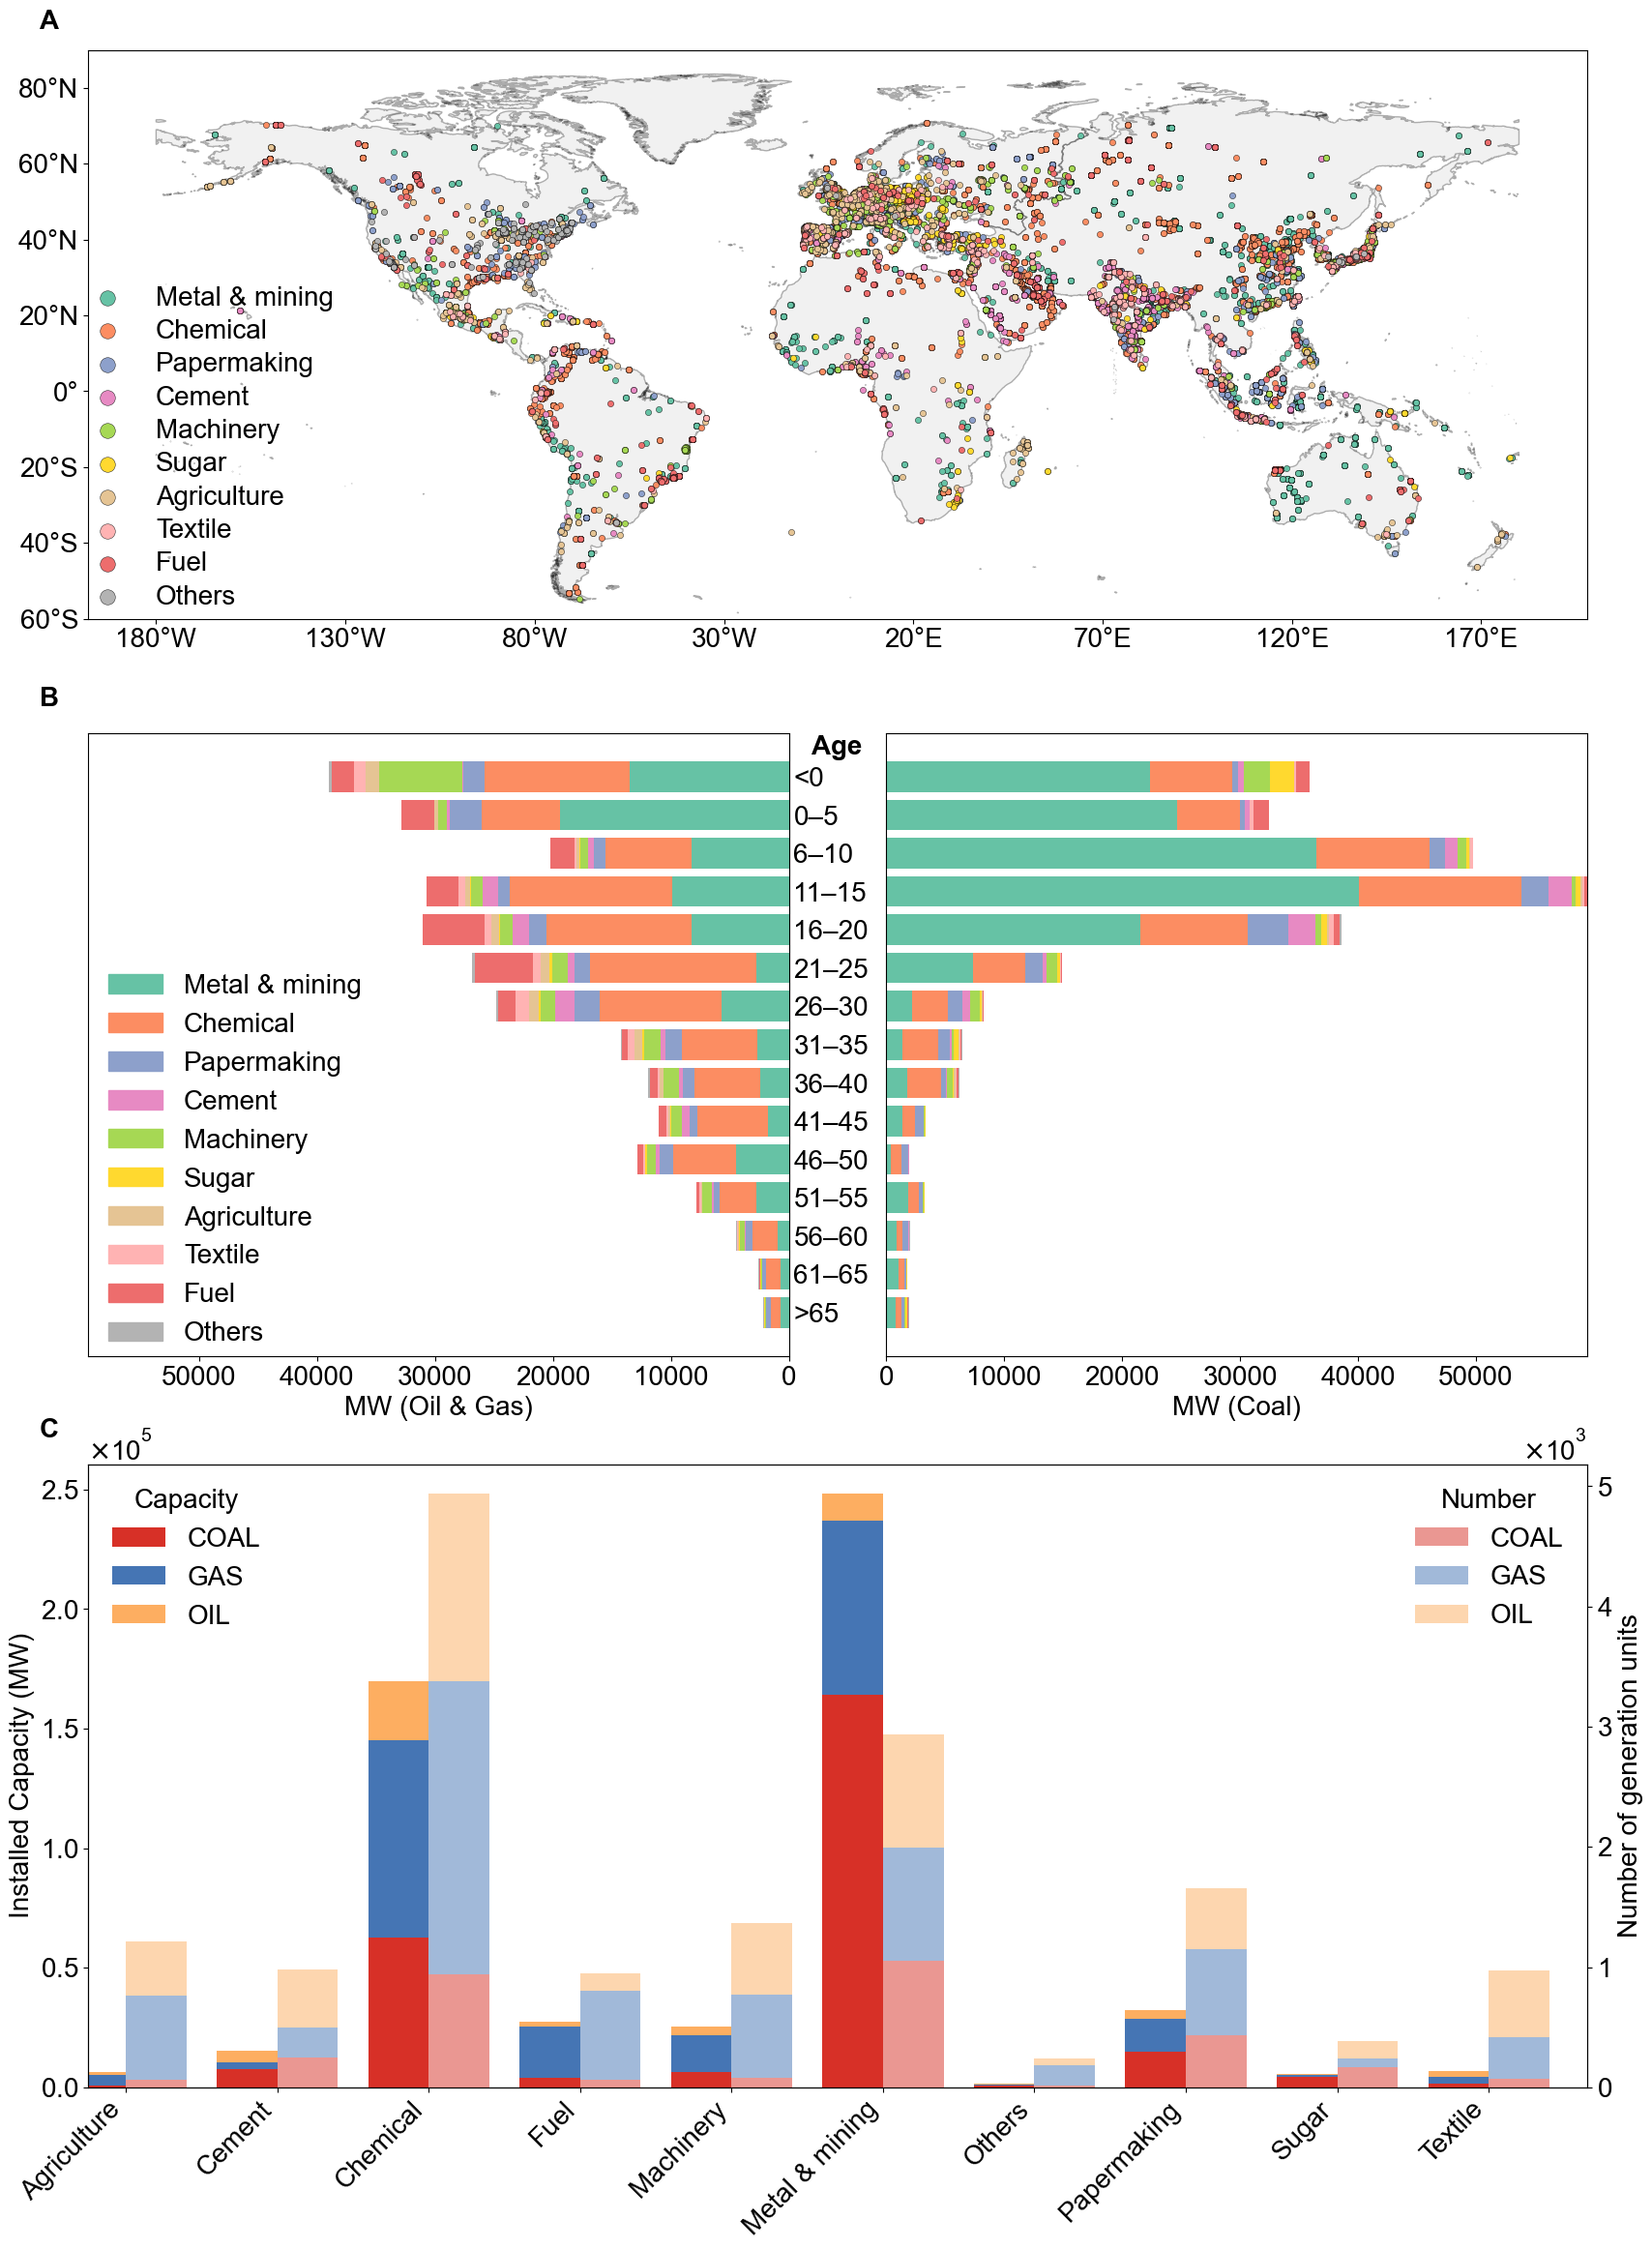

In [60]:
# -------------------------
# Unified color settings
# -------------------------
bustypes = ["Metal & mining", "Chemical", "Papermaking", "Cement", 
            "Machinery", "Sugar", "Agriculture", "Textile", "Fuel", "Others"]

color_map = {
    "Metal & mining": "#66c2a5",       # green
    "Chemical": "#fc8d62",  # orange
    "Papermaking": "#8da0cb",  # blue
    "Cement": "#e78ac3",       # pink
    "Machinery": "#a6d854",    # light green
    "Sugar": "#ffd92f",         # yellow
    "Agriculture": "#e5c494",   # light brown
    "Textile": "#ffb3b3",      # light red
    "Fuel": "#ED6D6D",        # red
    "Others": "#b3b3b3"        # gray
}

# Fuel color scheme for Figure 3
color_map2 = {
    'COAL': '#d73027',  # dark red
    'GAS': '#4575b4',   # blue
    'OIL': '#fdae61'    # orange
}

# -------------------------
# Create large Figure
# -------------------------
fig = plt.figure(figsize=(20,28))

################################## Figure 1 #################################################
ax1 = plt.subplot2grid((100,58), (1,0), rowspan=30, colspan=58)

# Plot world continent polygons
world.plot(ax=ax1, color='lightgray', edgecolor='black', alpha=0.3)

# Plot each bustype
for bustype in bustypes:
    subset = captive_plants_w_oil[captive_plants_w_oil['bustype_short'] == bustype]
    ax1.scatter(
        subset['longitude'],
        subset['latitude'],
        s=20,
        color=color_map[bustype],
        alpha=1,
        edgecolors='k',
        linewidths=0.3,
        label=bustype
    )

# Legend for bustypes
ax1.legend(
    fontsize=20,
    frameon=False, labelspacing=0.3, bbox_to_anchor=(0.18, 0.628),
    markerscale=2.5
)

ax1.set_ylim(-60, 90)
xticks = list(range(-180, 181, 50))
yticks = list(range(-60, 91, 20))

ax1.set_xticks(xticks)
ax1.set_yticks(yticks)

ax1.set_xticklabels([
    f"{abs(t)}°{'E' if t > 0 else 'W' if t < 0 else ''}"
    for t in xticks
])

ax1.set_yticklabels([
    f"{abs(t)}°{'N' if t > 0 else 'S' if t < 0 else ''}"
    for t in yticks
])

################################## Figure 2 #################################################
ax2 = plt.subplot2grid((100,58), (35,0), rowspan=30, colspan=58)
ax2.axis('off')

# Age bins
captive_plants_w_oil['age'] = 2025 - captive_plants_w_oil['year_adj']
bins = [-999, 0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 999]
labels = ["<0", "0–5", "6–10", "11–15", "16–20", "21–25", "26–30",
          "31–35", "36–40", "41–45", "46–50", "51–55", "56–60", "61–65", ">65"]
captive_plants_w_oil['age_bin'] = pd.cut(captive_plants_w_oil['age'], bins=bins, labels=labels, right=True)

# Separate fuel
coal_df = captive_plants_w_oil[captive_plants_w_oil['fuel_class'] == 'COAL']
oil_gas_df = captive_plants_w_oil[captive_plants_w_oil['fuel_class'].isin(['OIL','GAS'])]

# Pivot MW
coal_pivot = coal_df.pivot_table(index='age_bin', columns='bustype_short', values='mw', aggfunc='sum').fillna(0)
oil_gas_pivot = oil_gas_df.pivot_table(index='age_bin', columns='bustype_short', values='mw', aggfunc='sum').fillna(0)

coal_pivot = coal_pivot.reindex(labels)
oil_gas_pivot = oil_gas_pivot.reindex(labels)

bustype_order = bustypes
coal_pivot = coal_pivot.reindex(columns=bustype_order, fill_value=0)
oil_gas_pivot = oil_gas_pivot.reindex(columns=bustype_order, fill_value=0)

# Split ax2 into left/right insets
bbox = ax2.get_position()
fig = ax2.figure
gap = 0.065 * bbox.width
left_width = (bbox.width - gap) / 2
right_width = (bbox.width - gap) / 2

ax_left = fig.add_axes([bbox.x0, bbox.y0, left_width, bbox.height])
ax_right = fig.add_axes([bbox.x0 + left_width + gap, bbox.y0, right_width, bbox.height])

# Plot Oil & Gas (left)
left_bottom = pd.Series([0]*len(oil_gas_pivot), index=oil_gas_pivot.index)
for col in oil_gas_pivot.columns:
    ax_left.barh(oil_gas_pivot.index, oil_gas_pivot[col], left=left_bottom, color=color_map[col])
    left_bottom += oil_gas_pivot[col]
ax_left.invert_xaxis()
ax_left.invert_yaxis()
ax_left.set_xlabel("MW (Oil & Gas)")
ax_left.yaxis.set_label_position("right")
ax_left.yaxis.tick_right()
ax_left.tick_params(axis='y', which='both', length=0)

# Plot Coal (right)
right_bottom = pd.Series([0]*len(coal_pivot), index=coal_pivot.index)
for col in coal_pivot.columns:
    ax_right.barh(coal_pivot.index, coal_pivot[col], left=right_bottom, color=color_map[col])
    right_bottom += coal_pivot[col]
ax_right.invert_yaxis()
ax_right.set_xlabel("MW (Coal)")
ax_right.yaxis.set_visible(False)

# Symmetric x-axis
xmax = max(oil_gas_pivot.sum(axis=1).max(), coal_pivot.sum(axis=1).max())
ax_left.set_xlim(xmax, 0)
ax_right.set_xlim(0, xmax)

# Legend
handles = [Patch(color=color_map[col], label=col) for col in bustype_order]
fig.legend(
    handles=handles,
    fontsize=20, frameon=False, 
    title_fontsize=20,
    bbox_to_anchor=(0.201, 0.53),
    loc="upper center",
    ncol=1
)

fig.text(
    0.512, 0.6,
    "Age",
    ha='center', va='bottom',
    fontsize=20,
    fontweight='bold'
)

################################## Figure 3 #################################################
ax3 = plt.subplot2grid((100,58), (70,0), rowspan=30, colspan=58)
captive_plants_w_oil['bustype_short'] = captive_plants_w_oil['bustype'].map(bustype_labels)

# Capacity & count
capacity_grouped = captive_plants_w_oil.groupby(['bustype_short', 'fuel_class'])['mw'].sum().unstack(fill_value=0)
count_grouped = captive_plants_w_oil.groupby(['bustype_short', 'fuel_class'])['mw'].count().unstack(fill_value=0)

fuel_classes = list(capacity_grouped.columns)
fuel_colors = [color_map2[c] for c in fuel_classes]

width = 0.4
capacity_grouped.plot(
    kind="bar",
    stacked=True,
    ax=ax3,
    color=fuel_colors,
    width=width,
    position=1
)

ax3.set_ylabel("Installed Capacity (MW)")

ax33 = ax3.twinx()
count_grouped.plot(
    kind="bar",
    stacked=True,
    ax=ax33,
    color=fuel_colors,
    width=width,
    position=0,
    alpha=0.5
)
ax33.set_ylabel("Number of generation units")
ax3.set_xlabel(None)

ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha="right")
ax3.legend(title="Capacity", fontsize=20, loc="upper left", frameon=False)
ax33.legend(title="Number", fontsize=20, loc="upper right", frameon=False)

formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
formatter.set_useOffset(False)
ax3.yaxis.set_major_formatter(formatter)

formatter1 = ScalarFormatter(useMathText=True)
formatter1.set_scientific(True)
formatter1.set_powerlimits((0, 0))
formatter1.set_useOffset(False)
ax33.yaxis.set_major_formatter(formatter1)

################## Legend #######################
fig.text(0.1, 0.87, "A", fontsize=20, fontweight="bold")
fig.text(0.1, 0.62, "B", fontsize=20, fontweight="bold")
fig.text(0.1, 0.35, "C", fontsize=20, fontweight="bold")


#plt.show()
plt.savefig("./data/Figure_1.png", dpi=200, bbox_inches='tight')

# Figure 2

In [61]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

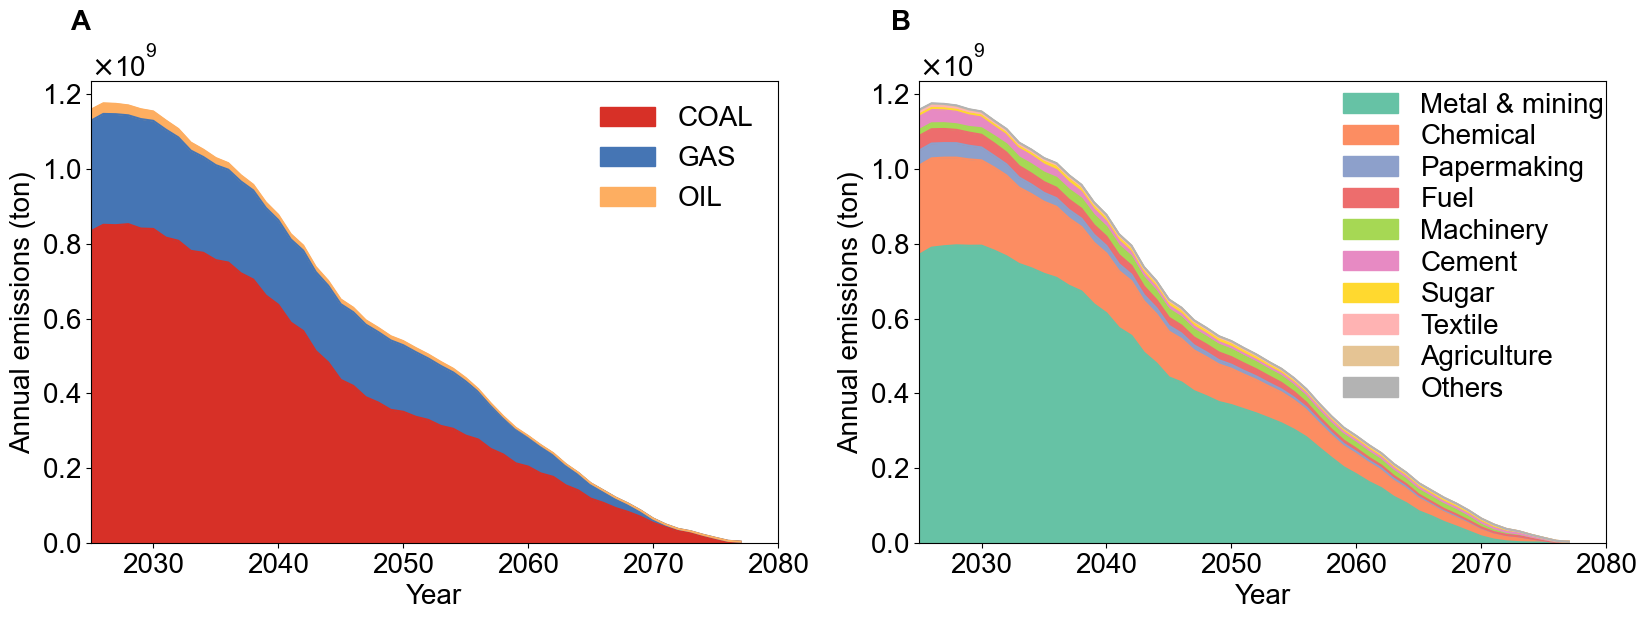

In [62]:
# -------------------------
# Color settings
# -------------------------
color_map = {
    "Metal & mining": "#66c2a5",       # green
    "Chemical": "#fc8d62",  # orange
    "Papermaking": "#8da0cb",  # blue
    "Cement": "#e78ac3",       # pink
    "Machinery": "#a6d854",    # light green
    "Sugar": "#ffd92f",         # yellow
    "Agriculture": "#e5c494",   # light brown
    "Textile": "#ffb3b3",      # light red
    "Fuel": "#ED6D6D",        # red
    "Others": "#b3b3b3"        # gray
}

color_map2 = {
    'COAL': '#d73027',  # dark red
    'GAS': '#4575b4',   # blue
    'OIL': '#fdae61'    # orange
}

# --- New: smoothing window size (years), larger = smoother, adjustable ---
smooth_window = 3

# -------------------------
# Create Figure
# -------------------------
fig = plt.figure(figsize=(20,8))

################################## Figure 1 #################################################
ax1 = plt.subplot2grid((40,90), (1,0), rowspan=30, colspan=40)

# --- New: smoothed copy for plotting only, does not overwrite original emissions_pivot_by_fuel ---
emissions_pivot_by_fuel_plot = (
    emissions_pivot_by_fuel
    .rolling(window=smooth_window, center=True, min_periods=1)
    .mean()
)

# Apply color_map2 to emissions_pivot_by_fuel
ax1_colors = [color_map2[col] if col in color_map2 else 'grey' for col in emissions_pivot_by_fuel_plot.columns]

emissions_pivot_by_fuel_plot.plot.area(
    ax=ax1,
    color=ax1_colors
)

formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))   # force scientific notation
formatter.set_useOffset(False)      # disable offset in top-left corner
ax1.yaxis.set_major_formatter(formatter)

ax1.set_xlim(2025, 2080)
ax1.set_xlabel("Year", fontsize=20)
ax1.set_ylabel("Annual emissions (ton)")
ax1.legend(fontsize=20, title_fontsize=20, frameon=False)

################################## Figure 2 #################################################
ax2 = plt.subplot2grid((40,90), (1,48), rowspan=30, colspan=40)

# Sort by total emissions per sector descending; highest-emission sector at bottom of stacked chart
bustype_order = (
    emissions_pivot_by_bustype.sum(axis=0)
    .sort_values(ascending=False)
    .index
)

# --- New: reorder columns by sorted order first, then create smoothed copy for plotting only; does not overwrite original emissions_pivot_by_bustype ---
emissions_pivot_by_bustype_plot = (
    emissions_pivot_by_bustype[bustype_order]
    .rolling(window=smooth_window, center=True, min_periods=1)
    .mean()
)

# Apply color_map to emissions_pivot_by_bustype
ax2_colors = [color_map[col] if col in color_map else 'grey' for col in emissions_pivot_by_bustype_plot.columns]

emissions_pivot_by_bustype_plot.plot.area(
    ax=ax2,
    color=ax2_colors
)

formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))   # force scientific notation
formatter.set_useOffset(False)      # disable offset in top-left corner
ax2.yaxis.set_major_formatter(formatter)

ax2.set_xlim(2025, 2080)
ax2.set_xlabel("Year", fontsize=20)
ax2.set_ylabel("Annual emissions (ton)")
ax2.legend(fontsize=20, title_fontsize=20, frameon=False, labelspacing=0.2, bbox_to_anchor=(0.58, 1.03))

################################# Legend #####################################
fig.text(0.115, 0.925, "A", fontsize=20, fontweight="bold")
fig.text(0.525, 0.925, "B", fontsize=20, fontweight="bold")

# -------------------------
# Save figure
# -------------------------
plt.savefig("./data/Figure_2.png", dpi=200, bbox_inches='tight')
#plt.show()

# Figure 3

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

selected_methods = [
    "solar", "wind", "grid", "ccs",
    "bio", "coaltogas", "bio_ccs",
    "40solar_grid", "40wind_grid"
]

# Bin edges and corresponding colors
cost_bins = [-float('inf'), 50, 100, 150, 200, 500, 1000, float('inf')]  # 6 intervals → 0~5
colors = ["#3b73b5", "#488ecb", "#5aa0d8", "#f2b94f", "#f9a71b", "#ea7644", "#d44729"]
cmap = LinearSegmentedColormap.from_list("cost_cmap", colors)
norm = BoundaryNorm(cost_bins, ncolors=cmap.N, clip=True)
color_dict = {i: c for i, c in enumerate(colors)}  # Color for each bin

In [64]:
iron_steel_list = [
    'Iron & Steel',
    'Iron',
    'Iron; Copper',
    'Iron & Steel; Aluminum',
    'Nickel; Iron & Steel',
    'Cold-Rolled Steel',
    'Steel',
    'Steel hot processing, not steelmaking',
    'iron & steel'
]
aluminum_list = [
    'Aluminum',
    'aluminum',
    'aluminum, iron & steel',
    'aluminum, other metals & mining',
    'aluminum, chemicals',
    'aluminum, nickel',
    'aluminum, industrial park, iron & steel'
]

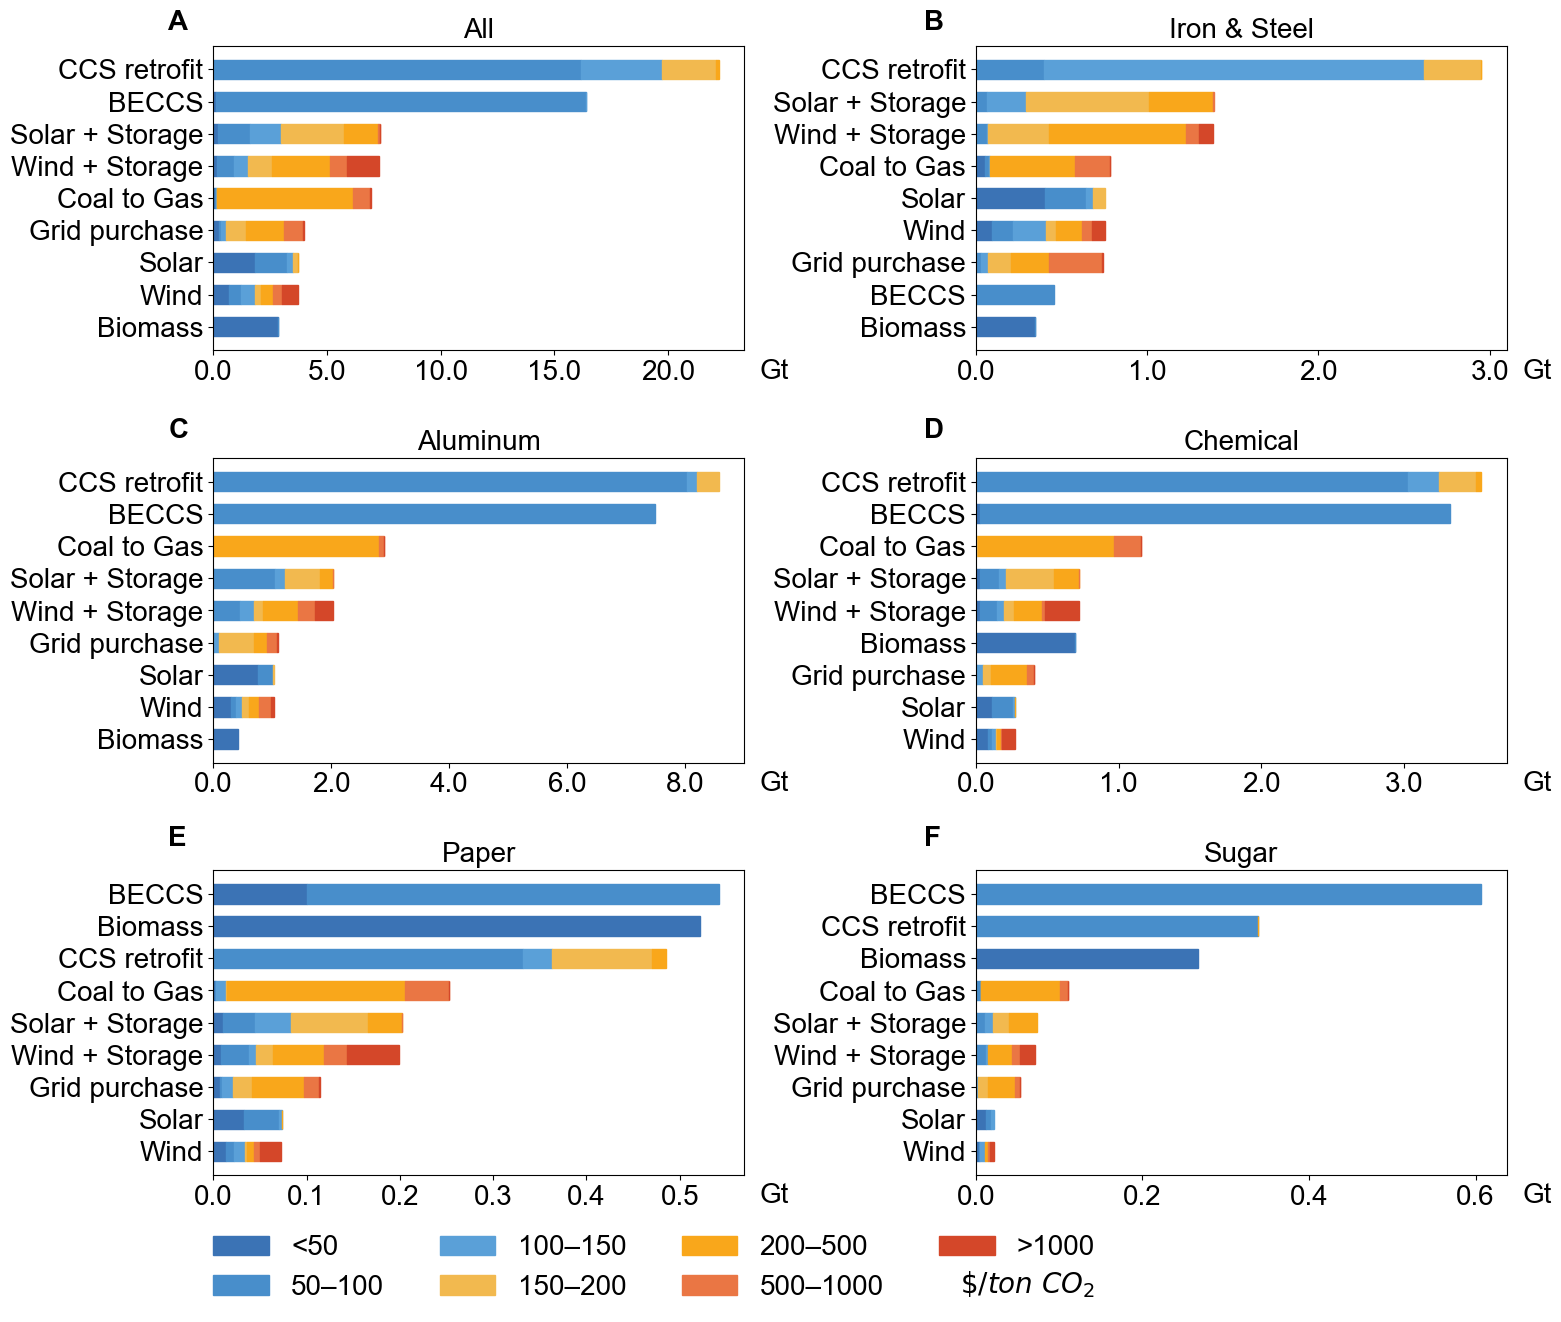

In [65]:
# 6 categories of captive plants
captive_list = [
    ("All", captive_plants),
    ("Iron & Steel", captive_plants[captive_plants['bustype_detail'].isin(iron_steel_list)]),
    ("Aluminum", captive_plants[captive_plants['bustype_detail'].isin(aluminum_list)]),
    ("Chemical", captive_plants[captive_plants['bustype'] == 'MFG: CHEMICALS & PETROCHE']),
    ("Paper", captive_plants[captive_plants['bustype'] == 'MFG: PULP & PAPER & FORES']),
    ("Sugar", captive_plants[captive_plants['bustype'] == 'MFG: SUGAR MILLS & FACTOR'])
]

# ==========================
# Canvas and grid settings
# ==========================
fig = plt.figure(figsize=(18, 16))  # wider canvas
nrows, ncols = 72, 110            # total grid size for easier control of subplot size and spacing

# 2 columns per row, each subplot occupies a large number of columns to leave spacing
rowspan = 18
colspan = 42
axes_positions = [
    (0,0,rowspan,colspan), (0,60,rowspan,colspan),
    (24,0,rowspan,colspan), (24,60,rowspan,colspan),
    (48,0,rowspan,colspan), (48,60,rowspan,colspan)
]

axes = []
for pos in axes_positions:
    row, col, rs, cs = pos
    ax = plt.subplot2grid((nrows,ncols), (row,col), rowspan=rs, colspan=cs)
    axes.append(ax)

# ==========================
# Loop to draw each subplot
# ==========================
feasibi_prefix_map = {
    "40solar_grid": "solar_grid",
    "40wind_grid": "wind_grid"
}

for idx, (name, df) in enumerate(captive_list):
    ax = axes[idx]
    y_pos = np.arange(len(selected_methods))
    bar_height = 0.6

    total_miti_dict = {}
    for m in selected_methods:
        miti_col = f"Miti_{m}"
        feasibi_prefix = feasibi_prefix_map.get(m, m)
        feasibi_col = f"feasibi_{feasibi_prefix}"
        feasible = df[df[feasibi_col] == 1]
        total_miti_dict[m] = feasible[miti_col].sum()

    selected_methods_sorted = sorted(selected_methods, key=lambda x: total_miti_dict[x], reverse=False)

    for i, m in enumerate(selected_methods_sorted):
        cost_col = f"cost_{m}"
        miti_col = f"Miti_{m}"
        feasibi_prefix = feasibi_prefix_map.get(m, m)
        feasibi_col = f"feasibi_{feasibi_prefix}"
        feasible = df[df[feasibi_col] == 1][[cost_col, miti_col]].copy()
        feasible['cost_bin'] = pd.cut(feasible[cost_col], bins=cost_bins, labels=False, right=False)
        sum_miti = feasible.groupby('cost_bin', observed=True)[miti_col].sum().reset_index()
        left = 0
        for _, row_data in sum_miti.iterrows():
            bin_idx = int(row_data['cost_bin'])
            if row_data[miti_col] > 0:
                ax.barh(
                    y=i,
                    width=row_data[miti_col],
                    height=bar_height,
                    left=left,
                    facecolor=color_dict[bin_idx],
                    edgecolor=color_dict[bin_idx]
                )
                left += row_data[miti_col]

    # Axis settings
    label_dict = {
    "solar": "Solar",
    "wind": "Wind",
    "grid": "Grid purchase",
    "ccs": "CCS retrofit",
    "bio": "Biomass",
    "coaltogas": "Coal to Gas",
    "bio_ccs": "BECCS",
    "40solar_grid": "Solar + Storage",
    "40wind_grid": "Wind + Storage"
    }
    
    new_labels = [label_dict[m] for m in selected_methods_sorted]
    ax.set_yticks(y_pos)
    ax.set_yticklabels(new_labels, fontsize=20)
    ax.tick_params(axis='x', labelsize=20)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1e9:.1f}"))
    ax.set_title(name, fontsize=20)
    ax.text(
        1.03,       # x=1.0 is far right; 1.01 is slightly to the right
        -0.028,      # y=-0.05 slightly below
        "Gt",
        ha='left',
        va='top',
        fontsize=20,
        transform=ax.transAxes   # use axes coordinates (0-1)
    )

# ==========================
# 6th subplot: legend
# ==========================

legend_elements = [
    Patch(facecolor="#3b73b5", edgecolor="#3b73b5", label="<50"),
    Patch(facecolor="#488ecb", edgecolor="#488ecb", label="50–100"),
    Patch(facecolor="#5aa0d8", edgecolor="#5aa0d8", label="100–150"),
    Patch(facecolor="#f2b94f", edgecolor="#f2b94f", label="150–200"),
    Patch(facecolor="#f9a71b", edgecolor="#f9a71b", label="200–500"),
    Patch(facecolor="#ea7644", edgecolor="#ea7644", label="500–1000"),
    Patch(facecolor="#d44729", edgecolor="#d44729", label=">1000")
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.37, 0.08),  # control vertical position
    ncol=4,                      # horizontal layout
    frameon=False
)
fig.text(
    0.54, 0.1058,
    r"$\$/ton\ CO_2$",
    ha="left",
    va="center",
    fontsize=20
)
# ========================== Add ABCD labels ###############
fig.text(0.1, 0.890, "A", fontsize=20, fontweight="bold")
fig.text(0.52, 0.890, "B", fontsize=20, fontweight="bold")
fig.text(0.1, 0.635, "C", fontsize=20, fontweight="bold")
fig.text(0.52, 0.635, "D", fontsize=20, fontweight="bold")
fig.text(0.1, 0.38, "E", fontsize=20, fontweight="bold")
fig.text(0.52, 0.38, "F", fontsize=20, fontweight="bold")


# ==========================
fig.subplots_adjust(wspace=0.3, hspace=0.4)  # wspace: horizontal spacing, hspace: vertical spacing

plt.savefig("./data/Figure_3.png", dpi=200, bbox_inches='tight')
#plt.show()

# Figure 4

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.lines import Line2D
from matplotlib.ticker import ScalarFormatter

# -----------------------------
# 1. World map
# -----------------------------
world = gpd.read_file(r'./data/DrawFigures/GlobalContinent/continent.shp')

# -----------------------------
# 2. Excel files and coordinate file
# -----------------------------
files = [
    r"./data/captive_power_plants/diverse_miti_target/least_cost_unit_level.xlsx",
    r"./data/captive_power_plants/diverse_miti_target/20pct_unit_level.xlsx",    
    r"./data/captive_power_plants/diverse_miti_target/40pct_unit_level.xlsx",
    r"./data/captive_power_plants/diverse_miti_target/60pct_unit_level.xlsx",
    r"./data/captive_power_plants/diverse_miti_target/most_miti_unit_level.xlsx"
]

gps_file = r"./data/captive_power_plants/Check_point_7.xlsx"
gps_df = pd.read_excel(gps_file)
gps = gps_df[['Plant_ID', 'longitude', 'latitude', 'bustype_short']]

# -----------------------------
# 3. Method name standardization function
# -----------------------------
def normalize_method(x):
    if pd.isna(x):
        return x
    x = x.replace("cost_", "")
    if "solar_grid" in x:
        return "solar_grid"
    if "wind_grid" in x:
        return "wind_grid"
    return x

# Store in dictionary
dfs = {}
names = ["least_cost", "20%_reduction", "40%_reduction", "60%_reduction","most_miti"]
for file, name in zip(files, names):
    df = pd.read_excel(file)
    df = df.merge(gps, on='Plant_ID', how='left')
    df['method_norm'] = df['method'].apply(normalize_method)
    dfs[name] = df

# Access pattern:
df_leastcost = dfs["least_cost"]
df_20reduction = dfs["20%_reduction"]
df_40reduction = dfs["40%_reduction"]
df_60reduction = dfs["60%_reduction"]
df_mostmiti = dfs["most_miti"]

# Add Country and Continent to df_leastcost etc.
plant_country = (
    captive_plants[["Plant_ID", "country_iso3"]]
    .drop_duplicates()
)
df_country = pd.read_excel(
    "./data/BasicData/GlobalCountryCode/CountryList.xlsx"
)
iso3_to_continent = dict(
    zip(df_country["Alpha-3 code"], df_country["Continent"])
)
dfs = [
    df_leastcost,
    df_20reduction,    
    df_40reduction,   
    df_60reduction,
    df_mostmiti
]
for i, df in enumerate(dfs):
    dfs[i] = df.merge(
        plant_country,
        on="Plant_ID",
        how="left"
    )
    dfs[i]["continent"] = dfs[i]["country_iso3"].map(iso3_to_continent)
df_leastcost, df_20reduction, df_40reduction, df_60reduction, df_mostmiti = dfs



# Color mapping
methods = [
    "no_action",
    "solar", "wind", "grid", "ccs", "bio_ccs", "coaltogas", "bio",
    "solar_grid", "wind_grid"
]
# Custom color dictionary
color_map = {
    "solar": "#FF9F00",        # golden orange
    "wind": "#42A5F5",         # bright blue
    "grid": "#616161",          # dark gray
    "ccs": "#B71C1C",          # dark burgundy
    "bio_ccs": "#E57373",      # light red, distinct from ccs
    "coaltogas": "#8D6E63",    # brown
    "bio": "#66BB6A",      # fresh green
    "solar_grid": "#FFE082",   # light orange
    "wind_grid": "#81D4FA",    # light blue
    "no_action": "#D9D9D9"            # very light gray
}

In [67]:
# Stacked chart data preparation
df_least = pd.read_excel(r"./data/captive_power_plants/diverse_miti_target/least_cost_unit_level.xlsx")
df_least['method_norm'] = df_least['method'].apply(normalize_method)
df_20 = pd.read_excel(r"./data/captive_power_plants/diverse_miti_target/20pct_unit_level.xlsx")
df_20['method_norm'] = df_20['method'].apply(normalize_method)
df_40 = pd.read_excel(r"./data/captive_power_plants/diverse_miti_target/40pct_unit_level.xlsx")
df_40['method_norm'] = df_40['method'].apply(normalize_method)
df_60 = pd.read_excel(r"./data/captive_power_plants/diverse_miti_target/60pct_unit_level.xlsx")
df_60['method_norm'] = df_60['method'].apply(normalize_method)
df_most = pd.read_excel(r"./data/captive_power_plants/diverse_miti_target/most_miti_unit_level.xlsx")
df_most['method_norm'] = df_most['method'].apply(normalize_method)


stack_least = df_least.groupby('method_norm')['miti'].sum()
stack_20 = df_20.groupby('method_norm')['miti'].sum()
stack_40 = df_40.groupby('method_norm')['miti'].sum()
stack_60 = df_60.groupby('method_norm')['miti'].sum()
stack_most = df_most.groupby('method_norm')['miti'].sum()

df_stack = pd.concat([stack_least, stack_most, stack_20, stack_40, stack_60], axis=1)
df_stack.columns = ['least_cost', 'most_miti',  '20%_reduction', '40%_reduction', '60%_reduction']

# Sort by total mitigation descending (largest at bottom)
df_stack = df_stack.loc[df_stack.sum(axis=1).sort_values(ascending=False).index]

In [68]:
# Regional statistics data preparation
def agg_by_continent(df, scenario):
    out = (
        df
        .groupby("continent", as_index=False)
        .agg(
            total_cost=("total_cost", "sum"),
            miti=("miti", "sum")
        )
    )
    out["cost_per_t"] = out["total_cost"] / out["miti"]
    out["scenario"] = scenario
    return out

continent_diff = pd.concat(
    [
        agg_by_continent(df_leastcost, "Least cost"),
        agg_by_continent(df_20reduction, "20% Reduction"),        
        agg_by_continent(df_40reduction, "40% Reduction"),
        agg_by_continent(df_60reduction, "60% Reduction"),
        agg_by_continent(df_mostmiti, "Most mitigation"),
    ],
    ignore_index=True
)

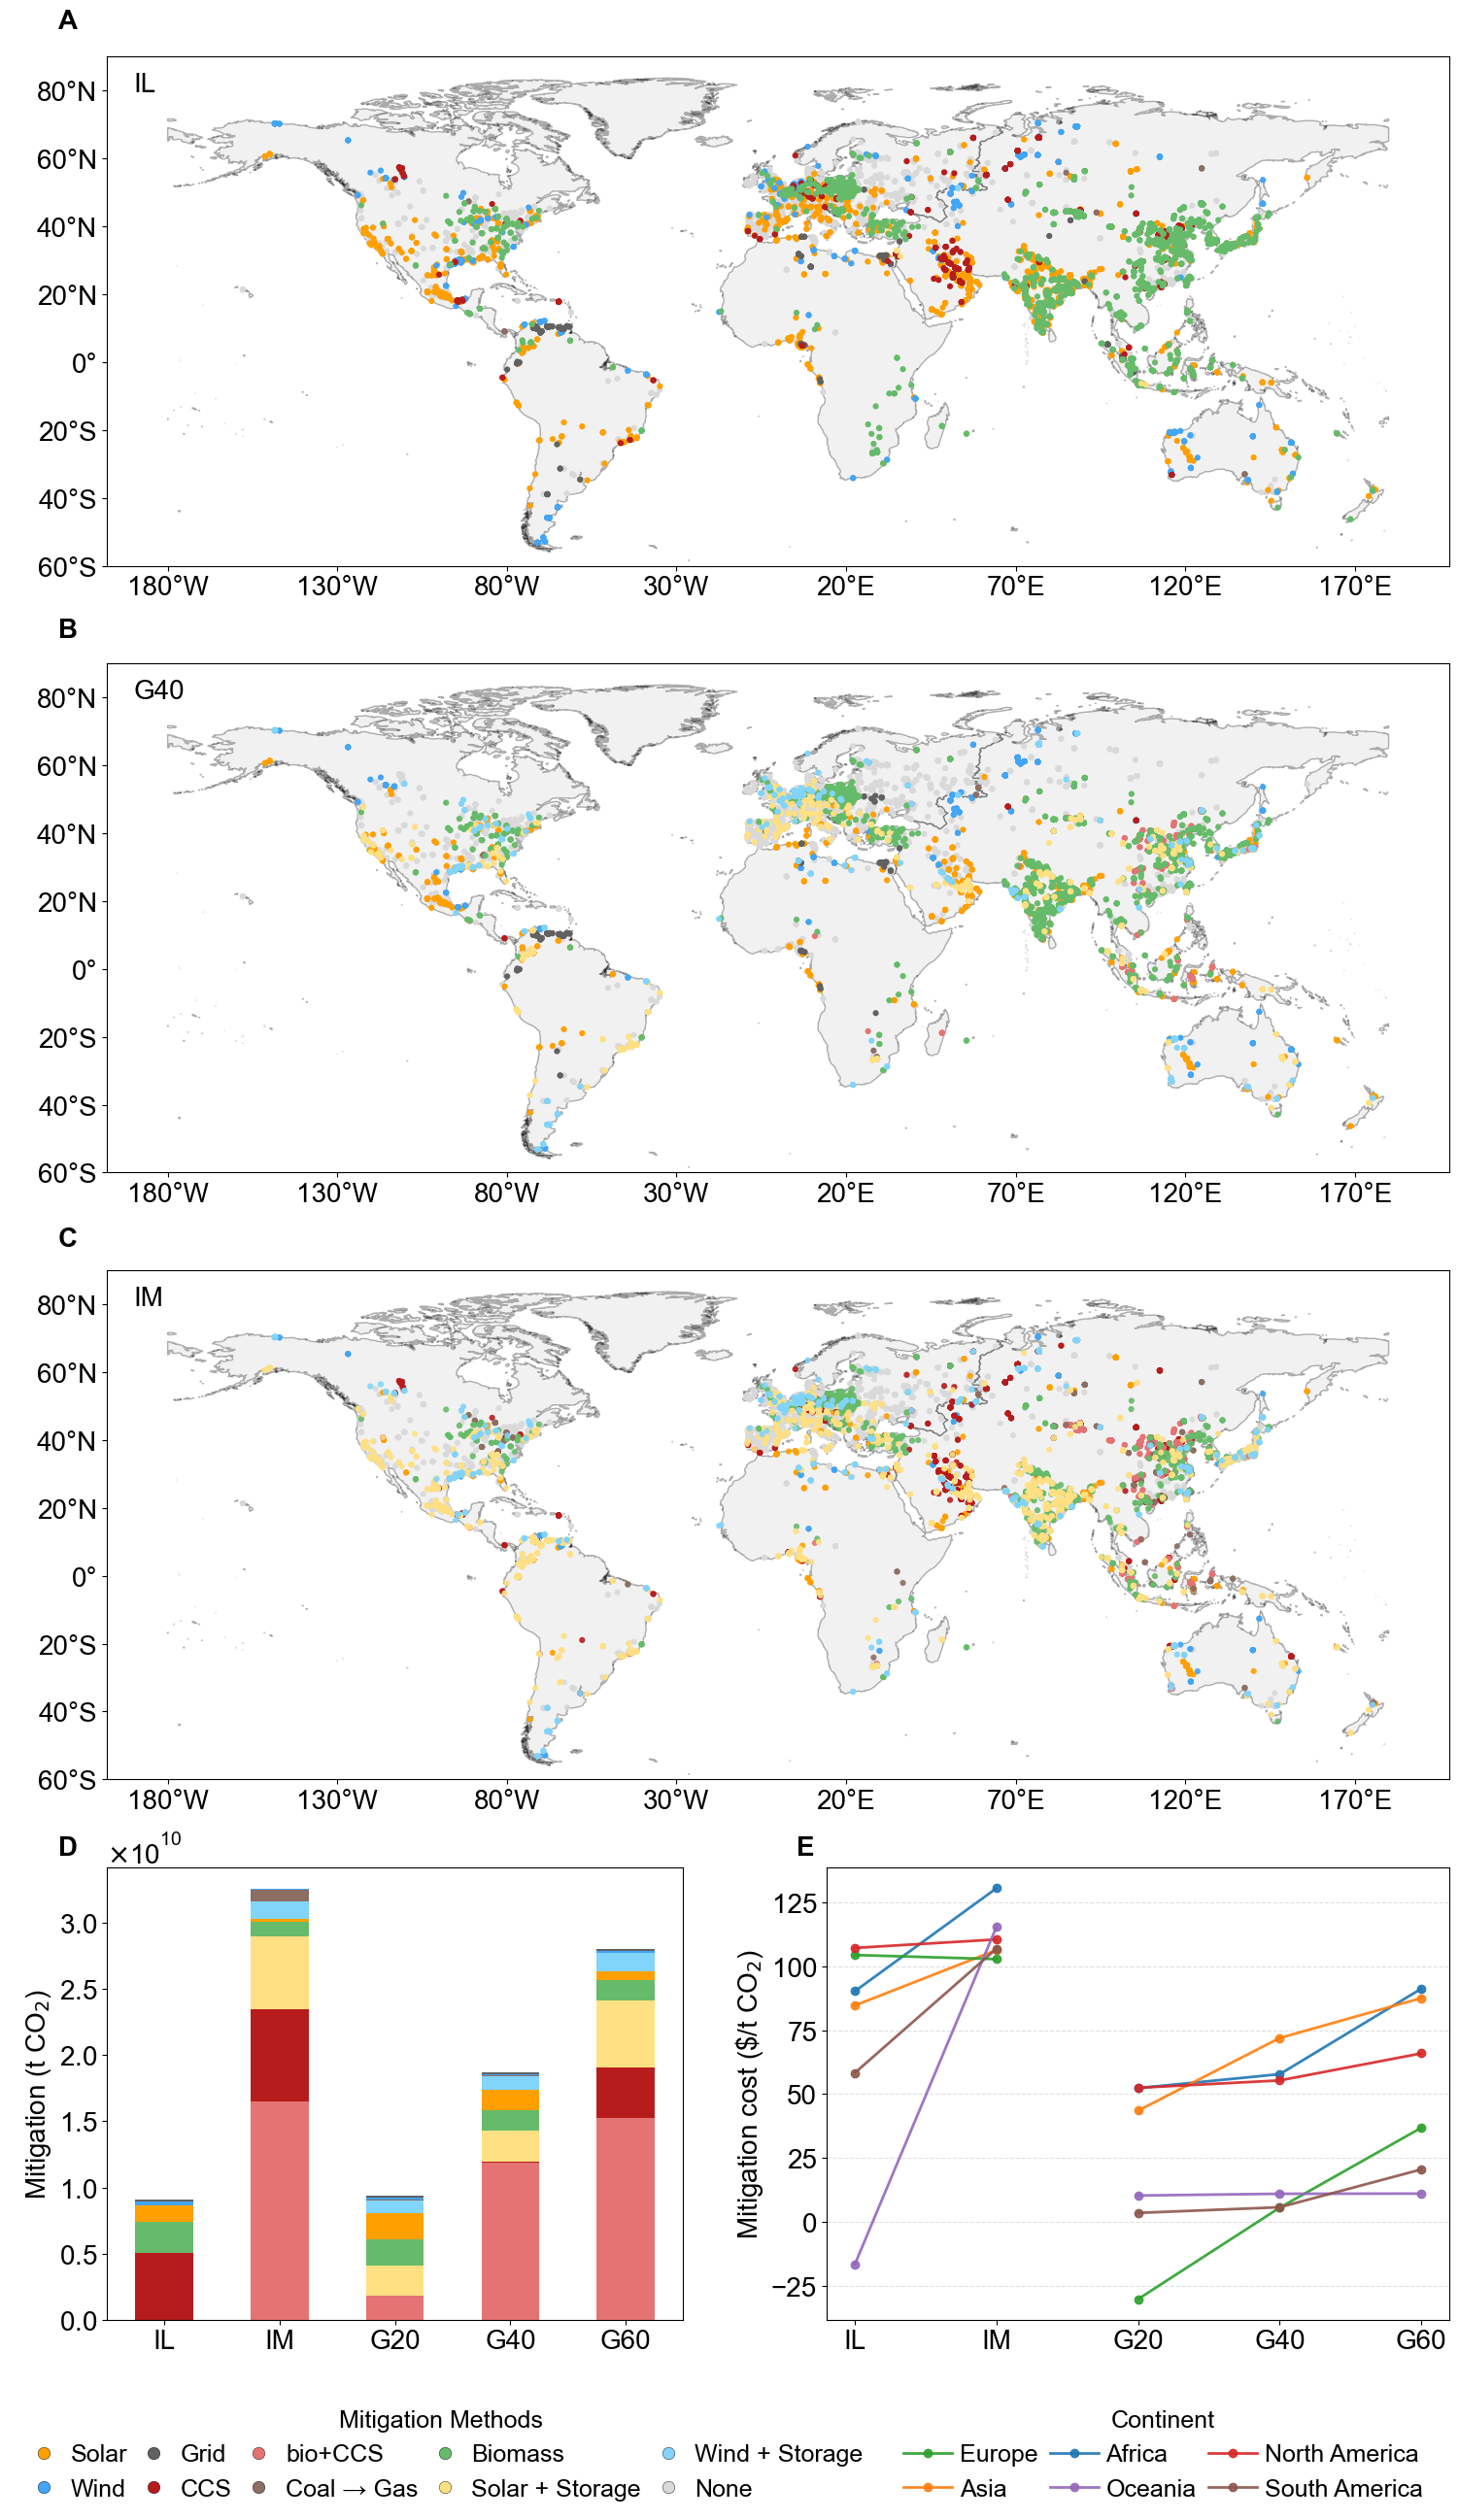

In [69]:
fig = plt.figure(figsize=(20, 38))

################################## Figure 1 #################################################
ax1 = plt.subplot2grid((150, 65), (1, 0), rowspan=28, colspan=58)

world.plot(ax=ax1, color='lightgray', edgecolor='black', alpha=0.3)

for m in methods:
    if m is None:
        subset = df_leastcost[df_leastcost['method_norm'].isna()]
        label_name = "None"
    else:
        subset = df_leastcost[df_leastcost['method_norm'] == m]
        label_name = m

    if len(subset) == 0:
        continue

    ax1.scatter(
        subset['longitude'],
        subset['latitude'],
        s=20,
        color=color_map[m],
        alpha=1,
        edgecolors='none',
        linewidths=0.2,
        label=label_name
    )

ax1.set_ylim(-60, 90)
xticks = list(range(-180, 181, 50))
yticks = list(range(-60, 91, 20))

ax1.set_xticks(xticks)
ax1.set_yticks(yticks)

ax1.set_xticklabels([f"{abs(t)}°{'E' if t > 0 else 'W' if t < 0 else ''}" for t in xticks])
ax1.set_yticklabels([f"{abs(t)}°{'N' if t > 0 else 'S' if t < 0 else ''}" for t in yticks])

ax1.text(0.02, 0.97, "IL", transform=ax1.transAxes,
         fontsize=20,  va="top", ha="left")

################################## Figure 2 #################################################
ax2 = plt.subplot2grid((150, 65), (33, 0), rowspan=28, colspan=58)

world.plot(ax=ax2, color='lightgray', edgecolor='black', alpha=0.3)

for m in methods:
    subset = df_40reduction[df_40reduction['method_norm'] == m]
    if len(subset) == 0:
        continue

    ax2.scatter(
        subset['longitude'],
        subset['latitude'],
        s=20,
        color=color_map[m],
        alpha=1,
        edgecolors='none',
        linewidths=0.2,
        label=m
    )

ax2.set_ylim(-60, 90)
ax2.set_xticks(xticks)
ax2.set_yticks(yticks)
ax2.set_xticklabels([f"{abs(t)}°{'E' if t > 0 else 'W' if t < 0 else ''}" for t in xticks])
ax2.set_yticklabels([f"{abs(t)}°{'N' if t > 0 else 'S' if t < 0 else ''}" for t in yticks])

ax2.text(0.02, 0.97, "G40", transform=ax2.transAxes,
         fontsize=20,  va="top", ha="left")

################################## Figure 3(formerly Figure 4) ##################################
ax3 = plt.subplot2grid((150, 65), (65, 0), rowspan=28, colspan=58)

world.plot(ax=ax3, color='lightgray', edgecolor='black', alpha=0.3)

for m in methods:
    subset = df_mostmiti[df_mostmiti['method_norm'] == m]
    if len(subset) == 0:
        continue

    ax3.scatter(
        subset['longitude'],
        subset['latitude'],
        s=20,
        color=color_map[m],
        alpha=0.9,
        edgecolors='none',
        linewidths=0.3,
        label=m
    )

ax3.set_ylim(-60, 90)
ax3.set_xticks(xticks)
ax3.set_yticks(yticks)
ax3.set_xticklabels([f"{abs(t)}°{'E' if t > 0 else 'W' if t < 0 else ''}" for t in xticks])
ax3.set_yticklabels([f"{abs(t)}°{'N' if t > 0 else 'S' if t < 0 else ''}" for t in yticks])

ax3.text(0.02, 0.97, "IM", transform=ax3.transAxes,
         fontsize=20,  va="top", ha="left")

################################## Figure 4(bar chart) ########################################
ax4 = plt.subplot2grid((150, 65), (97, 0), rowspan=24, colspan=25)

# Reorder by new scenario order
new_col_order = ['least_cost','most_miti', '20%_reduction','40%_reduction', '60%_reduction']
df_stack_plot = df_stack[new_col_order]

df_stack_plot.T.plot(
    kind='bar',
    stacked=True,
    color=[color_map.get(x, "#D9D9D9") for x in df_stack_plot.index],
    ax=ax4
)

ax4.set_ylabel(r"Mitigation (t CO$_2$)")
ax4.set_xticks(range(len(df_stack_plot.columns)))
ax4.set_xticklabels(['IL', 'IM', 'G20', 'G40', 'G60'], rotation=0)

formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
formatter.set_useOffset(False)
ax4.yaxis.set_major_formatter(formatter)


################################## Figure 5(line chart) ########################################
ax5 = plt.subplot2grid((150, 65), (97, 31), rowspan=24, colspan=27)

scenario_order = [
    "Least cost",
    "Most mitigation",
    "20% Reduction",
    "40% Reduction",
    "60% Reduction"
]

df_plot = continent_diff.copy()
df_plot["scenario"] = pd.Categorical(df_plot["scenario"], categories=scenario_order, ordered=True)
df_plot = df_plot.sort_values(["continent", "scenario"])

x = range(len(scenario_order))

for continent, g in df_plot.groupby("continent"):
    g = g.set_index("scenario").reindex(scenario_order)
    
    # First two points (IL, IM)
    ax5.plot(
        list(x)[:2],
        g["cost_per_t"].values[:2],
        marker="o",
        linewidth=2,
        alpha=0.9,
        label=continent
    )
    # Last three points (G20, G40, G60), no label to avoid legend duplication
    ax5.plot(
        list(x)[2:],
        g["cost_per_t"].values[2:],
        marker="o",
        linewidth=2,
        alpha=0.9,
        color=ax5.lines[-1].get_color(),  # keep same color
        label="_nolegend_"
    )

ax5.set_xticks(list(x))
ax5.set_xticklabels(['IL', 'IM', 'G20', 'G40', 'G60'])
ax5.set_ylabel(r"Mitigation cost (\$/t CO$_2$)")

ax5.grid(axis="y", linestyle="--", alpha=0.4)

handles, labels = ax5.get_legend_handles_labels()
order = ['Europe', 'Asia', 'Africa', 'Oceania', 'North America', 'South America']
handles = [handles[labels.index(l)] for l in order if l in labels]
labels = [l for l in order if l in labels]

leg = ax5.legend(
    handles=handles,
    labels=labels,
    loc='upper center',
    bbox_to_anchor=(0.54, -0.15),
    ncol=3,
    handletextpad=0.3,
    columnspacing=0.5,
    title_fontsize=18,
    fontsize=18,
    title="Continent",
    frameon=True
)

leg.get_frame().set_alpha(0.0)
leg.get_frame().set_edgecolor('none')


################################## Legend (methods) ##############################################
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Solar', 
           markerfacecolor=color_map['solar'], markersize=9, markeredgecolor='k', markeredgewidth=0.3),
    Line2D([0], [0], marker='o', color='w', label='Wind',
           markerfacecolor=color_map['wind'], markersize=9, markeredgecolor='k', markeredgewidth=0.3),
    Line2D([0], [0], marker='o', color='w', label='Grid',
           markerfacecolor=color_map['grid'], markersize=9, markeredgecolor='k', markeredgewidth=0.3),
    Line2D([0], [0], marker='o', color='w', label='CCS',
           markerfacecolor=color_map['ccs'], markersize=9, markeredgecolor='k', markeredgewidth=0.3),
    Line2D([0], [0], marker='o', color='w', label='bio+CCS',
           markerfacecolor=color_map['bio_ccs'], markersize=9, markeredgecolor='k', markeredgewidth=0.3),    
    Line2D([0], [0], marker='o', color='w', label='Coal → Gas',
           markerfacecolor=color_map['coaltogas'], markersize=9, markeredgecolor='k', markeredgewidth=0.3),
    Line2D([0], [0], marker='o', color='w', label='Biomass',
           markerfacecolor=color_map['bio'], markersize=9, markeredgecolor='k', markeredgewidth=0.3),
    Line2D([0], [0], marker='o', color='w', label='Solar + Storage',
           markerfacecolor=color_map['solar_grid'], markersize=9, markeredgecolor='k', markeredgewidth=0.3),
    Line2D([0], [0], marker='o', color='w', label='Wind + Storage',
           markerfacecolor=color_map['wind_grid'], markersize=9, markeredgecolor='k', markeredgewidth=0.3),
    Line2D([0], [0], marker='o', color='w', label='None',
           markerfacecolor=color_map['no_action'], markersize=9, markeredgecolor='k', markeredgewidth=0.3),
]

ax4.legend(
    handles=legend_elements,
    loc='upper center',      # legend anchor: upper center
    bbox_to_anchor=(0.58, -0.15),  # horizontally centered, placed slightly below subplot
    frameon=False,
    framealpha=1,
    ncol=5,                    # fewer columns, narrower legend, easier to align with map width
    handletextpad=0.1,         # spacing between legend marker and text
    columnspacing=0.1,         # column spacing
    title_fontsize=18,
    fontsize=18,
    title="Mitigation Methods"
)


################################## ABCDE ####################################################
fig.text(0.1, 0.880, "A", fontsize=20, fontweight="bold")
fig.text(0.1, 0.715, "B", fontsize=20, fontweight="bold")
fig.text(0.1, 0.550, "C", fontsize=20, fontweight="bold")
fig.text(0.1, 0.385, "D", fontsize=20, fontweight="bold")
fig.text(0.48, 0.385, "E", fontsize=20, fontweight="bold")

#plt.show()
plt.savefig("./data/Figure_4.png", dpi=200, bbox_inches='tight')

# Figure 5

In [70]:
import seaborn as sns
######################################################Subplot 1 data###########################################
df_fig5 = (
    df_leastcost[
        ["Plant_ID_High", "Plant_ID", "bustype_short", "method_norm", "cost_per_t", "total_cost", "miti"]
    ]
    .rename(columns={
        "method_norm": "method_norm_least",
        "cost_per_t": "cost_per_t_least",
        "total_cost": "total_cost_least",
        "miti": "miti_least",
    })
    .merge(
        df_20reduction[
            ["Plant_ID", "method_norm", "cost_per_t", "total_cost", "miti"]
        ].rename(columns={
            "method_norm": "method_norm_20",
            "cost_per_t": "cost_per_t_20",
            "total_cost": "total_cost_20",
            "miti": "miti_20",
        }),
        on="Plant_ID",
        how="outer",
    )
    .merge(
        df_40reduction[
            ["Plant_ID", "method_norm", "cost_per_t", "total_cost", "miti"]
        ].rename(columns={
            "method_norm": "method_norm_40",
            "cost_per_t": "cost_per_t_40",
            "total_cost": "total_cost_40",
            "miti": "miti_40",
        }),
        on="Plant_ID",
        how="outer",
    )
    .merge(
        df_60reduction[
            ["Plant_ID", "method_norm", "cost_per_t", "total_cost", "miti"]
        ].rename(columns={
            "method_norm": "method_norm_60",
            "cost_per_t": "cost_per_t_60",
            "total_cost": "total_cost_60",
            "miti": "miti_60",
        }),
        on="Plant_ID",
        how="outer",
    )
    .merge(
        df_mostmiti[
            ["Plant_ID", "method_norm", "cost_per_t", "total_cost", "miti"]
        ].rename(columns={
            "method_norm": "method_norm_most",
            "cost_per_t": "cost_per_t_most",
            "total_cost": "total_cost_most",
            "miti": "miti_most",
        }),
        on="Plant_ID",
        how="outer",
    )
)

# Stacked chart data
busty_stack_least = df_fig5.groupby('bustype_short')['miti_least'].sum()
busty_stack_20 = df_fig5.groupby('bustype_short')['miti_20'].sum()
busty_stack_40 = df_fig5.groupby('bustype_short')['miti_40'].sum()
busty_stack_60 = df_fig5.groupby('bustype_short')['miti_60'].sum()
busty_stack_most = df_fig5.groupby('bustype_short')['miti_most'].sum()

busty_df_stack = pd.concat([busty_stack_least, busty_stack_most, busty_stack_20, busty_stack_40, busty_stack_60], axis=1)
busty_df_stack.columns = ['least_cost', 'most_miti', '20%_reduction', '40%_reduction', '60%_reduction']

In [71]:
########################################Subplot 3 data############################################
scenario_map = {
    "least": "Least cost",
    "20": "20% Reduction",
    "40": "40% Reduction",
    "60": "60% Reduction",
    "most": "Most mitigation"
}

records = []

for sc_key, sc_name in scenario_map.items():
    cost_col = f"cost_per_t_{sc_key}"
    miti_col = f"miti_{sc_key}"
    method_col = f"method_norm_{sc_key}"

    if cost_col not in df_fig5.columns:
        continue

    sub = df_fig5[
        ["Plant_ID_High", "Plant_ID", "bustype_short", cost_col, miti_col, method_col]
    ].copy()

    sub = sub.rename(columns={
        cost_col: "cost_per_t",
        miti_col: "miti",
        method_col: "method_norm"
    })

    sub["scenario"] = sc_name
    records.append(sub)

df_long = pd.concat(records, ignore_index=True)

# Clean invalid values
df_long = df_long.replace([np.inf, -np.inf], np.nan)
df_long = df_long.dropna(subset=["cost_per_t", "miti"])
df_long = df_long[df_long["miti"] > 0]

scenario_order = [
    "Least cost",
    "Most mitigation",
    "20% Reduction",
    "40% Reduction",
    "60% Reduction"
]

# Key: set as ordered categorical variable
df_long["scenario"] = pd.Categorical(
    df_long["scenario"],
    categories=scenario_order,
    ordered=True
)

df_grouped = (
    df_long.groupby(["scenario", "bustype_short"])
      .apply(lambda x: np.average(x["cost_per_t"], weights=x["miti"]))
      .reset_index(name="weighted_cost")
)

C:\Users\18470\AppData\Local\Temp\ipykernel_7300\2205247827.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_long.groupby(["scenario", "bustype_short"])
C:\Users\18470\AppData\Local\Temp\ipykernel_7300\2205247827.py:57: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.average(x["cost_per_t"], weights=x["miti"]))


In [72]:
########################################Subplot 2 data############################################
def weighted_quantile(values, quantiles, sample_weight):
    values = np.array(values)
    quantiles = np.array(quantiles)
    sample_weight = np.array(sample_weight)

    sorter = np.argsort(values)
    values = values[sorter]
    sample_weight = sample_weight[sorter]

    weighted_cdf = np.cumsum(sample_weight) / np.sum(sample_weight)

    return np.interp(quantiles, weighted_cdf, values)

box_stats = []

for sc in scenario_order:
    sub = df_long[df_long["scenario"] == sc]

    if sub.empty:
        continue

    q05, q10, q50, q90, q95 = weighted_quantile(
        sub["cost_per_t"],
        [0.05, 0.25, 0.5, 0.75, 0.95],
        sub["miti"]
    )
    
    mean_cost = np.average(
        sub.loc[sub["cost_per_t"].between(q05, q95), "cost_per_t"],
        weights=sub.loc[sub["cost_per_t"].between(q05, q95), "miti"]
    )
  
    box_stats.append({
        "label": sc,
        "q1": q10,
        "med": mean_cost,
        "q3": q90,
        "whislo": q05,   # change to P10 for wider whiskers
        "whishi": q95
    })

# Figure 5_1

<>:157: SyntaxWarning: invalid escape sequence '\$'
<>:198: SyntaxWarning: invalid escape sequence '\$'
<>:157: SyntaxWarning: invalid escape sequence '\$'
<>:198: SyntaxWarning: invalid escape sequence '\$'
C:\Users\18470\AppData\Local\Temp\ipykernel_7300\3033188842.py:157: SyntaxWarning: invalid escape sequence '\$'
  ax2.set_ylabel("Abatement cost (\$/t CO$_2$)")
C:\Users\18470\AppData\Local\Temp\ipykernel_7300\3033188842.py:198: SyntaxWarning: invalid escape sequence '\$'
  ax.set_ylabel("Abatement cost (\$/t CO$_2$)")
C:\Users\18470\AppData\Local\Temp\ipykernel_7300\3033188842.py:142: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['IL', 'IM', 'G20', 'G40', 'G60'], rotation=0, ha='center')
C:\Users\18470\AppData\Local\Temp\ipykernel_7300\3033188842.py:210: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
 

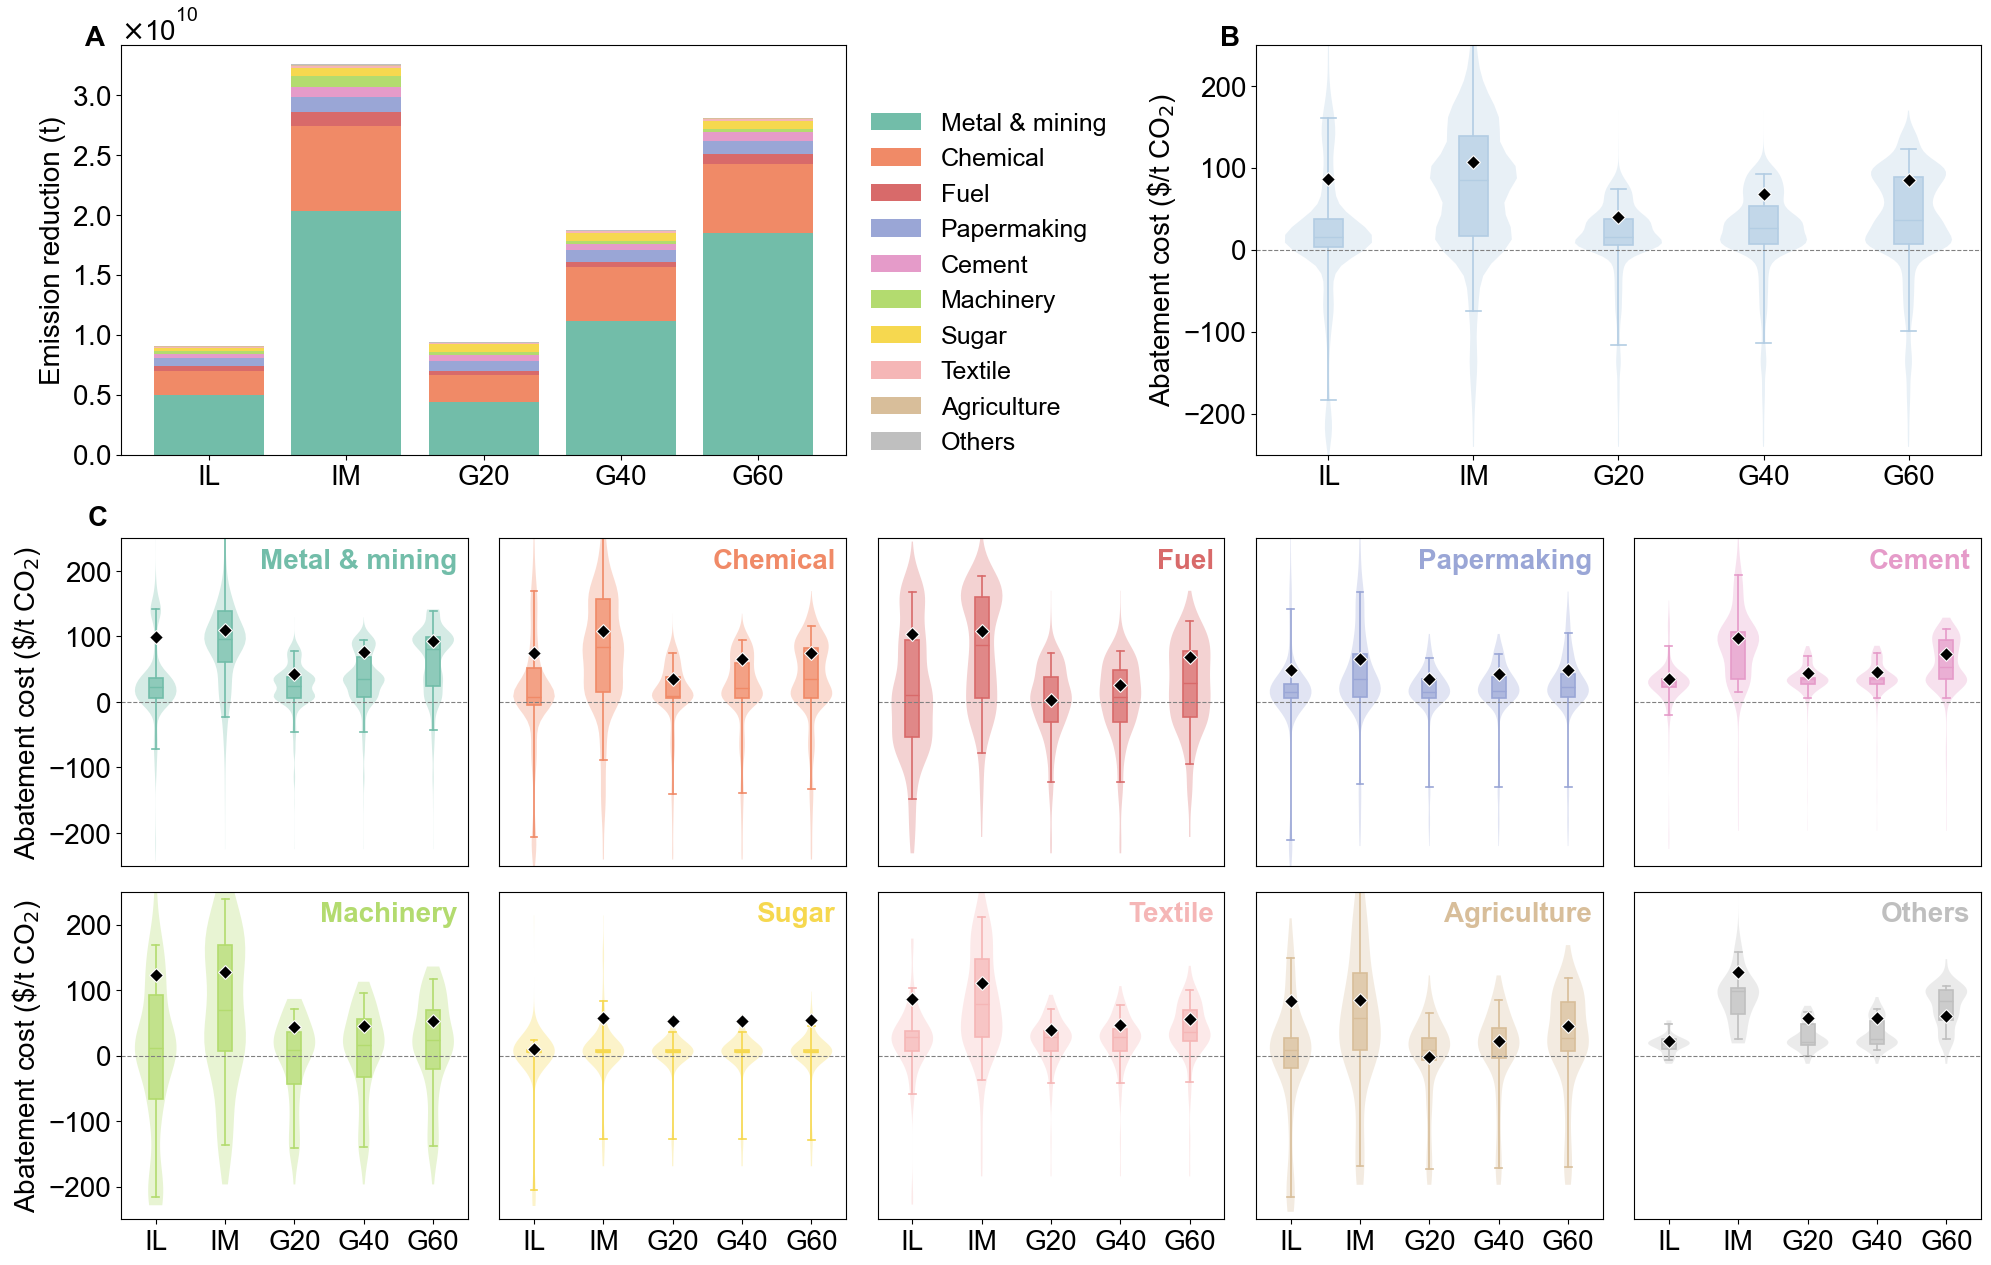

In [73]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter

color_map2 = {
    "Metal & mining":      "#72bda9",
    "Chemical":   "#f08a67",
    "Papermaking": "#9aa6d6",
    "Cement":      "#e59bc9",
    "Machinery":   "#b3db6f",
    "Sugar":       "#f6d84f",
    "Agriculture": "#d8be9a",
    "Textile":     "#f5b6b6",
    "Fuel":       "#d86a6a",
    "Others":      "#bfbfbf"
}

industry_order = (
    busty_df_stack['most_miti']
    .sort_values(ascending=False)
    .index.tolist()
)

# ── Helper functions ──────────────────────────────────────────
def lighten_color(hex_color, factor=0.5):
    rgb   = np.array(mcolors.to_rgb(hex_color))
    white = np.array([1, 1, 1])
    return tuple(rgb + (white - rgb) * factor)

def get_clipped_data(sc, industry=None):
    sub = df_long[df_long["scenario"] == sc].dropna(subset=["cost_per_t", "miti"])
    if industry:
        sub = sub[sub["bustype_short"] == industry]
    if sub.empty or len(sub) < 2:
        return np.array([]), np.array([])
    vals = sub["cost_per_t"].values
    weights = sub["miti"].values
    return vals, weights

def draw_violin_box(ax, data_by_scenario, positions, base_color="#B3CDE3"):
    violin_color = lighten_color(base_color, factor=0.5)
    box_color    = lighten_color(base_color, factor=0.2)

    valid_idx  = [i for i, (v, w) in enumerate(data_by_scenario) if len(v) > 1]
    valid_data = [data_by_scenario[i][0] for i in valid_idx]
    valid_pos  = [positions[i] for i in valid_idx]

    if valid_data:
        vp = ax.violinplot(
            valid_data, positions=valid_pos,
            widths=0.6, showextrema=False, showmedians=False
        )
        for body in vp["bodies"]:
            body.set_facecolor(violin_color)
            body.set_alpha(0.6)
            body.set_edgecolor("none")

    box_stats = []
    weighted_avgs = []
    for i in valid_idx:
        vals, weights = data_by_scenario[i]

        q05, q25, q75, q95 = np.percentile(vals, [5, 25, 75, 95])
        weighted_avg = np.average(vals, weights=weights)
        weighted_avgs.append(weighted_avg)

        box_stats.append({
            "label": scenario_order[i],
            "q1": q25, "med": q50 if False else np.median(vals),  # true median, dimmed display
            "q3": q75,
            "whislo": q05, "whishi": q95
        })

    if box_stats:
        bp = ax.bxp(
            box_stats, positions=valid_pos, widths=0.2,
            showfliers=False, patch_artist=True
        )
        for patch in bp["boxes"]:
            patch.set_facecolor(box_color)
            patch.set_edgecolor(base_color)
            patch.set_linewidth(1.2)
        for element in ["whiskers", "caps"]:
            for line in bp[element]:
                line.set_color(base_color)
                line.set_linewidth(1.2)
        # Median line: thinner and lighter, as auxiliary reference
        for line in bp["medians"]:
            line.set_color(base_color)
            line.set_linewidth(1)
            line.set_alpha(1)

    # Weighted average cost: marked with black diamond, more prominent
    for pos, avg in zip(valid_pos, weighted_avgs):
        ax.scatter(pos, avg, marker='D', s=50,
                   color='black', edgecolor='white',
                   linewidth=0.8, zorder=10)

    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_xticks(positions)
    ax.set_xticklabels(['IL', 'IM', 'G20', 'G40', 'G60'], rotation=0, ha='center')

# ── Layout ──────────────────────────────────────────────
fig = plt.figure(figsize=(24, 16))

NROW           = 150
NCOL           = 10

TOP_ROWSPAN    = 50
BOTTOM_ROWSPAN = 40
TOP_START      = 0
BOT1_START     = TOP_ROWSPAN + 10
BOT2_GAP       = 3
BOT2_START     = BOT1_START + BOTTOM_ROWSPAN + BOT2_GAP

positions = list(range(1, 6))
industries_sorted = [ind for ind in industry_order
                     if ind in df_long["bustype_short"].unique()]

# ── Subplot A: stacked bar, left half (col 0-4) ──────────
ax1 = plt.subplot2grid((NROW, NCOL), (TOP_START, 0),
                        rowspan=TOP_ROWSPAN, colspan=4)

busty_df_stack_sorted = busty_df_stack.loc[industry_order]
x      = busty_df_stack_sorted.columns
bottom = np.zeros(len(x))

for industry in busty_df_stack_sorted.index:
    values = busty_df_stack_sorted.loc[industry].values
    ax1.bar(x, values, bottom=bottom,
            color=color_map2.get(industry, "#D9D9D9"), label=industry)
    bottom += values

formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
formatter.set_useOffset(False)
ax1.yaxis.set_major_formatter(formatter)
ax1.tick_params(axis='x', rotation=0)
ax1.set_ylabel("Emission reduction (t)")
ax1.set_xticklabels(['IL', 'IM', 'G20', 'G40', 'G60'], rotation=0, ha='center')
ax1.legend(fontsize=18, frameon=False,
           loc='upper left',
           bbox_to_anchor=(1.02, 0.86),
           borderaxespad=0)
ax1.text(-0.05, 1, "A",
         transform=ax1.transAxes,
         fontsize=20, fontweight="bold")

# ── Subplot B: overall violin, right half (col 5-9) ───────
ax2 = plt.subplot2grid((NROW, NCOL), (TOP_START, 6),
                        rowspan=TOP_ROWSPAN, colspan=5)

data_all = [get_clipped_data(sc) for sc in scenario_order]
draw_violin_box(ax2, data_all, positions, base_color="#B3CDE3")
ax2.set_ylabel("Abatement cost (\$/t CO$_2$)")
ax2.set_ylim(-250, 250)
ax2.text(-0.05, 1, "B",
         transform=ax2.transAxes,
         fontsize=20, fontweight="bold")

# ── Industry subplots: create all axes, store in list ───────────────
industry_axes = []
for idx, industry in enumerate(industries_sorted):
    row_start = BOT1_START if idx < 5 else BOT2_START
    col_start = (idx % 5) * 2
    ax = plt.subplot2grid((NROW, NCOL), (row_start, col_start),
                           rowspan=BOTTOM_ROWSPAN, colspan=2)
    industry_axes.append(ax)

# ── C label: derived from first industry axis position, no new axis ────────
first_ax_pos = industry_axes[0].get_position()
fig.text(
    first_ax_pos.x0-0.014,
    first_ax_pos.y1 + 0.008,
    "C", fontsize=20, fontweight="bold"
)

# ── Draw each industry ────────────────────────────────────────
for idx, (industry, ax) in enumerate(zip(industries_sorted, industry_axes)):
    col_start = (idx % 5) * 2
    row       = idx // 5  # 0 = first row, 1 = second row

    base_color = color_map2.get(industry, "#D9D9D9")
    data_ind   = [get_clipped_data(sc, industry) for sc in scenario_order]
    draw_violin_box(ax, data_ind, positions, base_color=base_color)

    ax.set_ylim(-250, 250)

    ax.text(0.97, 0.97, industry,
            transform=ax.transAxes,
            fontsize=20, fontweight="bold", color=base_color,
            va='top', ha='right')

    # Keep y-axis only on leftmost column
    if col_start == 0:
        ax.set_ylabel("Abatement cost (\$/t CO$_2$)")
    else:
        ax.yaxis.set_ticklabels([])
        ax.yaxis.set_ticks_position('none')

    # Keep x-axis only on bottom row
    if row == 0:
        ax.xaxis.set_ticklabels([])
        ax.xaxis.set_ticks_position('none')

    ax.tick_params(axis='both', labelsize=20)

plt.tight_layout(h_pad=3.0, w_pad=3.0)
plt.savefig("./data/Figure_5.png", dpi=200, bbox_inches='tight')